# OCP Youssoufia SCADA Digital Twin — Full EDA
`youssoufia_pandapower_dataset_dataset.csv` · 11 substations · 36,000 timesteps @ 1 Hz (10 h) · 396,000 rows

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi':110, 'axes.grid':True, 'grid.alpha':.3, 'font.size':10})
sns.set_palette('tab10')

DATA_PATH = r"C:\Users\21270\Desktop\internship_ocp\simulation\3. AI\dataset\train.csv"
df = pd.read_csv(DATA_PATH)

NUMERIC = ['V_hv_kV','V_lv_kV','I_hv_A','P_MW','Q_Mvar','S_MVA','PF','loading_pct','freq_Hz']
CATEG   = ['substation','equip_status','breaker_status','relay_status','label','lifecycle_stage','fault_location']
SUBS    = sorted(df.substation.unique())
LABELS  = df.label.value_counts().index.tolist()

df.shape


(330000, 20)

## 1. Schema, Cardinality & Memory Footprint

In [2]:

schema = df.dtypes.to_frame('dtype').assign(
    n_unique=df.nunique(),
    n_missing=df.isna().sum(),
    pct_missing=(df.isna().mean()*100).round(3),
    sample=[df[c].dropna().iloc[0] for c in df.columns]
)
schema


,dtype,n_unique,n_missing,pct_missing,sample
time_s,int64,150,0,0.000,0
substation,object,11,0,0.000,Laverie/Sechage SN1
episode_id,int64,200,0,0.000,0
V_hv_kV,float64,24337,343,0.104,45.895
V_lv_kV,float64,3077,343,0.104,4.037
I_hv_A,float64,13092,343,0.104,84.64
P_MW,float64,5265,343,0.104,5.785
Q_Mvar,float64,5035,343,0.104,2.887
S_MVA,float64,7082,343,0.104,6.465
PF,float64,522,343,0.104,0.895


In [3]:

print(f"Memory footprint: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Time range: {df.time_s.min()}–{df.time_s.max()} s  |  dt = {np.diff(sorted(df.time_s.unique()[:5]))[0]} s  |  {df.time_s.nunique()} unique steps")
print(f"Substations ({len(SUBS)}): {SUBS}")
print(f"Exact duplicate (time_s, substation) keys: {df.duplicated(subset=['time_s','substation']).sum()}")
print(f"Fully duplicate rows: {df.duplicated().sum()}")
# every substation must appear at every timestep -> balanced panel check
panel_counts = df.groupby('substation').time_s.nunique()
print("Balanced panel (all subs have 36000 steps):", (panel_counts == df.time_s.nunique()).all())


Memory footprint: 222.7 MB
Time range: 0–149 s  |  dt = 1 s  |  150 unique steps
Substations (11): ['Laverie/Sechage SN1', 'Laverie/Sechage SN2', 'Mine Mzinda DIS TR', 'PSF Mine Bouchane SN6', 'Recette 3 SN3', 'Recette 9 SN9', 'SSP Local ST1', 'SSP Local ST2', 'U Calcination SN1', 'U Calcination SN2', 'U Calcination SN3']
Exact duplicate (time_s, substation) keys: 328350
Fully duplicate rows: 0
Balanced panel (all subs have 36000 steps): True


In [4]:
df[NUMERIC].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
V_hv_kV,329657.0,54.258,13.334,0.000,56.044,59.272,60.179,61.857
V_lv_kV,329657.0,4.899,1.213,0.000,5.069,5.353,5.435,6.578
I_hv_A,329657.0,54.846,129.662,0.000,15.440,30.230,62.770,5777.230
P_MW,329657.0,2.912,2.187,0.000,1.280,2.672,4.380,92.019
Q_Mvar,329657.0,1.769,5.994,0.000,0.657,1.251,2.679,288.300
S_MVA,329657.0,3.490,6.336,0.000,1.456,2.979,5.303,290.294
PF,329657.0,0.846,0.178,0.000,0.843,0.889,0.913,0.994
loading_pct,329657.0,76.233,121.267,0.000,30.420,44.710,57.200,2500.000
freq_Hz,330000.0,50.005,0.218,48.486,49.991,50.000,50.009,51.201


In [5]:

for c in CATEG:
    print(f"--- {c} ({df[c].nunique()} unique) ---")
    print(df[c].value_counts().to_dict())
    print()


--- substation (11 unique) ---
{'Laverie/Sechage SN1': 30000, 'Laverie/Sechage SN2': 30000, 'Mine Mzinda DIS TR': 30000, 'PSF Mine Bouchane SN6': 30000, 'Recette 3 SN3': 30000, 'Recette 9 SN9': 30000, 'U Calcination SN1': 30000, 'U Calcination SN2': 30000, 'U Calcination SN3': 30000, 'SSP Local ST1': 30000, 'SSP Local ST2': 30000}

--- equip_status (5 unique) ---
{'HEALTHY': 308256, 'OFFLINE': 16001, 'DEGRADED': 4440, 'FAULTED': 761, 'OVERLOADED': 542}

--- breaker_status (4 unique) ---
{'CLOSED': 313446, 'OPEN': 16001, 'TRIP_COMMAND': 321, 'OPENING': 232}

--- relay_status (11 unique) ---
{'NORMAL': 174300, 'ALARM': 86145, 'MONITORING': 34781, 'TRIPPED': 16455, 'RESET': 7128, 'ALARM_81O': 5146, 'PICKUP_81U': 2619, 'ALARM_81U': 1725, 'PICKUP_81O': 1382, 'PICKUP': 307, 'OPERATED': 12}

--- label (9 unique) ---
{'normal': 255000, 'voltage_sag': 21450, 'over_frequency': 21450, 'under_frequency': 13200, 'lg_fault': 8850, 'll_fault': 7800, 'overload': 1800, 'transformer_trip': 300, 'breaker

## 2. Data Quality Audit

**2.1 Missing values**

In [6]:

miss_rows = df[df.isna().any(axis=1)]
print(f"{len(miss_rows)} rows ({len(miss_rows)/len(df)*100:.3f}%) with NaNs, spanning {miss_rows.isna().any().sum()} columns simultaneously")
display_cols = ['time_s','substation','label','lifecycle_stage','equip_status']
miss_rows[display_cols].label.value_counts()


20780 rows (6.297%) with NaNs, spanning 9 columns simultaneously


label
voltage_sag        20459
normal               258
over_frequency        32
under_frequency       15
ll_fault               6
overload               5
lg_fault               5
Name: count, dtype: int64

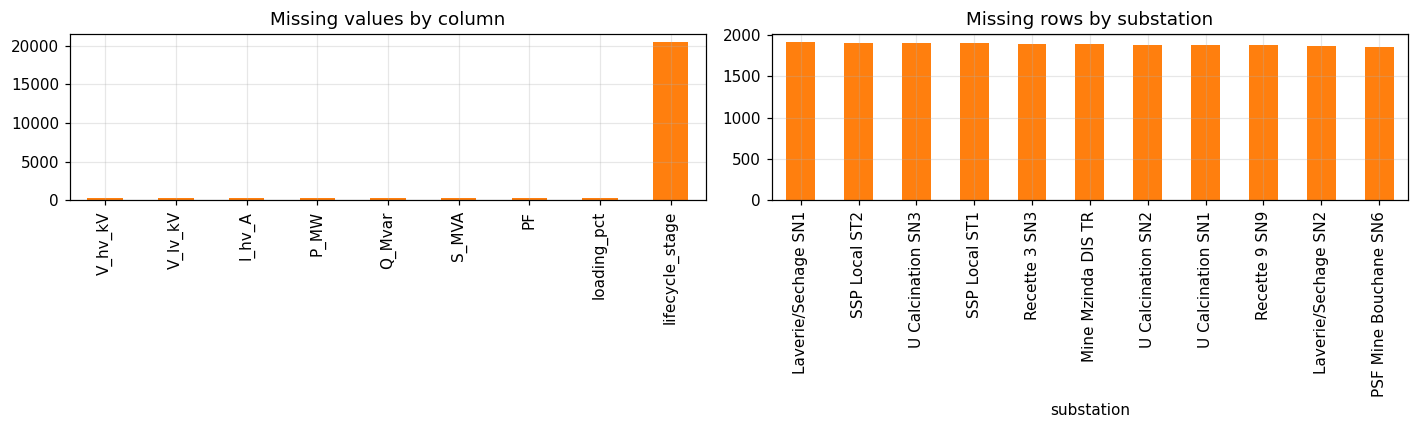

In [7]:

fig, axes = plt.subplots(1,2, figsize=(13,4))
df.isna().sum()[df.isna().sum()>0].plot.bar(ax=axes[0], color='tab:orange', title='Missing values by column')
miss_rows.substation.value_counts().plot.bar(ax=axes[1], color='tab:orange', title='Missing rows by substation')
plt.tight_layout(); plt.show()


In [8]:

# are missing rows clustered around lifecycle transitions?
miss_rows.lifecycle_stage.value_counts()


lifecycle_stage
normal            258
restored           33
pre_fault          14
isolated           13
relay_operated      2
fault_detected      1
Name: count, dtype: int64

**2.2 Label ↔ status consistency** — rows labeled `normal` should show `equip_status == HEALTHY`, `breaker_status == CLOSED`, `relay_status` in {NORMAL, ALARM, MONITORING}

In [9]:

normal = df[df.label=='normal']
bad_equip   = normal[normal.equip_status != 'HEALTHY']
bad_breaker = normal[normal.breaker_status != 'CLOSED']
bad_relay   = normal[~normal.relay_status.isin(['NORMAL','ALARM','MONITORING'])]

summary = pd.Series({
    "bad equip_status"  : len(bad_equip),
    "bad breaker_status": len(bad_breaker),
    "bad relay_status"  : len(bad_relay),
}).to_frame('n_rows').assign(pct_of_normal=lambda d: (d.n_rows/len(normal)*100).round(3))
summary


,n_rows,pct_of_normal
bad equip_status,0,0.0
bad breaker_status,0,0.0
bad relay_status,0,0.0


In [10]:
pd.crosstab(df.label, df.equip_status)

equip_status,DEGRADED,FAULTED,HEALTHY,OFFLINE,OVERLOADED
label,,,,,
breaker_trip,0,31,71,48,0
lg_fault,2004,348,3090,3408,0
ll_fault,1829,316,3238,2417,0
normal,0,0,255000,0,0
over_frequency,0,0,15272,6178,0
overload,607,7,606,38,542
transformer_trip,0,59,123,118,0
under_frequency,0,0,9406,3794,0
voltage_sag,0,0,21450,0,0


In [11]:
pd.crosstab(df.label, df.relay_status)

relay_status,ALARM,ALARM_81O,ALARM_81U,MONITORING,NORMAL,OPERATED,PICKUP,PICKUP_81O,PICKUP_81U,RESET,TRIPPED
label,,,,,,,,,,,
breaker_trip,0,0,0,0,0,0,30,0,0,71,49
lg_fault,0,0,0,2004,0,0,115,0,0,3090,3641
ll_fault,0,0,0,1829,0,0,105,0,0,3238,2628
normal,64165,0,0,16535,174300,0,0,0,0,0,0
over_frequency,0,5146,0,8744,0,0,0,1382,0,0,6178
overload,530,0,0,607,0,12,0,0,0,606,45
transformer_trip,0,0,0,0,0,0,57,0,0,123,120
under_frequency,0,0,1725,5062,0,0,0,0,2619,0,3794
voltage_sag,21450,0,0,0,0,0,0,0,0,0,0


In [12]:

bad_equip.groupby(['substation','equip_status']).size().unstack(fill_value=0)


equip_status
substation


**2.3 Physical plausibility bounds**

In [13]:

checks = {
    'PF outside [0,1]'        : ~df.PF.between(0,1),
    'loading_pct > 150%'      : df.loading_pct > 150,
    'V_hv_kV > 70 (>1.15pu)'  : df.V_hv_kV > 70,
    'V_hv_kV < 0'             : df.V_hv_kV < 0,
    'freq_Hz outside 45-55'   : ~df.freq_Hz.between(45,55),
    'I_hv_A < 0'              : df.I_hv_A < 0,
    'S < sqrt(P^2+Q^2)-1 (inconsistent S)': (df.S_MVA - np.sqrt(df.P_MW**2+df.Q_Mvar**2)).abs() > 0.5,
}
pd.Series({k:int(v.sum()) for k,v in checks.items()}, name='n_violations').to_frame()


,n_violations
"PF outside [0,1]",343
loading_pct > 150%,30269
V_hv_kV > 70 (>1.15pu),0
V_hv_kV < 0,0
freq_Hz outside 45-55,0
I_hv_A < 0,0
S < sqrt(P^2+Q^2)-1 (inconsistent S),0


In [14]:
df.nlargest(5, 'loading_pct')[['time_s','substation','label','equip_status','loading_pct','I_hv_A']]

,time_s,substation,label,equip_status,loading_pct,I_hv_A
8505,23,Mine Mzinda DIS TR,lg_fault,FAULTED,2500.0,3777.12
8516,24,Mine Mzinda DIS TR,lg_fault,FAULTED,2500.0,3803.24
8527,25,Mine Mzinda DIS TR,lg_fault,FAULTED,2500.0,3776.11
8538,26,Mine Mzinda DIS TR,lg_fault,FAULTED,2500.0,3794.91
15260,37,PSF Mine Bouchane SN6,lg_fault,FAULTED,2500.0,2705.37


## 3. Target / Label Structure

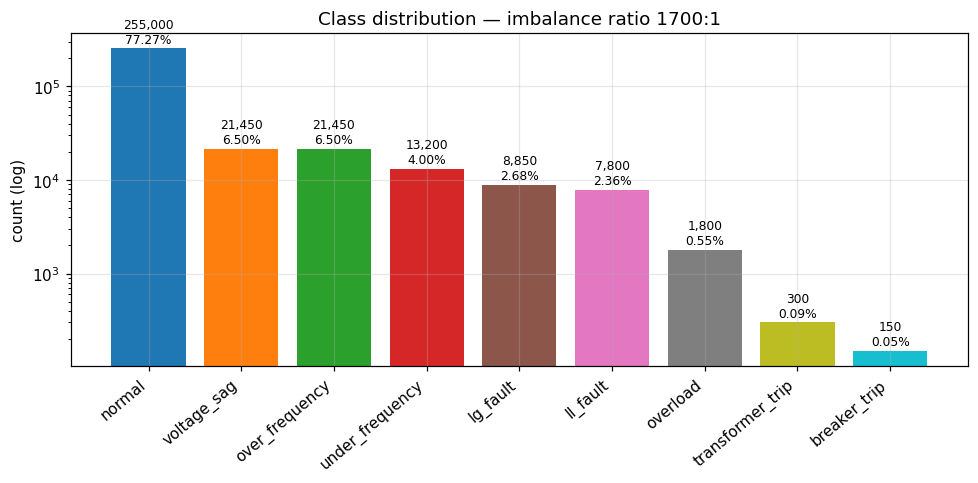

In [15]:

counts = df.label.value_counts()
fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10(np.linspace(0,1,len(counts))))
ax.set_yscale('log'); ax.set_ylabel('count (log)')
for b,v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v*1.15, f'{v:,}\n{v/len(df)*100:.2f}%', ha='center', fontsize=8)
plt.xticks(rotation=40, ha='right'); ax.set_title(f'Class distribution — imbalance ratio {counts.max()/counts.min():.0f}:1')
plt.tight_layout(); plt.show()


In [16]:

d = df.sort_values(['substation','time_s']).copy()
d['block'] = (d['label'] != d.groupby('substation')['label'].shift()).cumsum()
events = (d[d.label!='normal']
          .groupby(['substation','block','label'])
          .agg(start=('time_s','min'), end=('time_s','max'), duration=('time_s','count'))
          .reset_index())
print(f"{len(events)} discrete fault EVENTS from {len(df[df.label!='normal']):,} fault TIMESTEPS")
events.groupby('label')['duration'].agg(['count','mean','std','min','max']).round(1)


71250 discrete fault EVENTS from 75,000 fault TIMESTEPS


,count,mean,std,min,max
label,,,,,
breaker_trip,150,1.0,0.0,1,1
lg_fault,8400,1.1,0.2,1,2
ll_fault,7800,1.0,0.0,1,1
over_frequency,21450,1.0,0.0,1,1
overload,1800,1.0,0.0,1,1
transformer_trip,300,1.0,0.0,1,1
under_frequency,11550,1.1,0.3,1,2
voltage_sag,19800,1.1,0.3,1,2


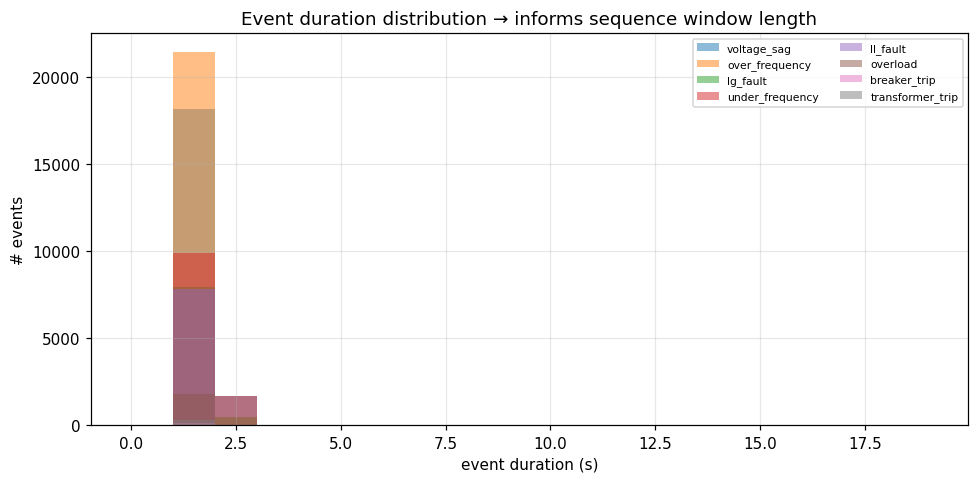

In [17]:

fig, ax = plt.subplots(figsize=(9,4.5))
for lab in events.label.unique():
    ax.hist(events[events.label==lab].duration, bins=range(0,20), alpha=.5, label=lab)
ax.set_xlabel('event duration (s)'); ax.set_ylabel('# events'); ax.legend(fontsize=7, ncol=2)
ax.set_title('Event duration distribution → informs sequence window length')
plt.tight_layout(); plt.show()


**Lifecycle stage sequence per event** — verifies the state machine (`pre_fault → fault_detected → relay_operated → breaker_open → isolated`)

In [18]:
stage_seq = (
    d.sort_values(['substation', 'time_s'])
     .groupby(['substation', 'block'])['lifecycle_stage']
     .apply(lambda s: ' → '.join(pd.unique(s.dropna().astype(str))))
)

stage_seq[stage_seq != 'normal'].value_counts().head(15)

lifecycle_stage
restored                      20647
                              18812
isolated                      14941
pre_fault                     11831
fault_detected                 1785
relay_operated                 1145
restored → isolated             550
breaker_open                    220
isolated → pre_fault             88
fault_detected → pre_fault       55
isolated → fault_detected        55
isolated → relay_operated        44
relay_operated → pre_fault       44
isolated → restored              15
pre_fault → fault_detected        6
Name: count, dtype: int64

## 4. Whole-Dataset Time Series (system-level, all substations)

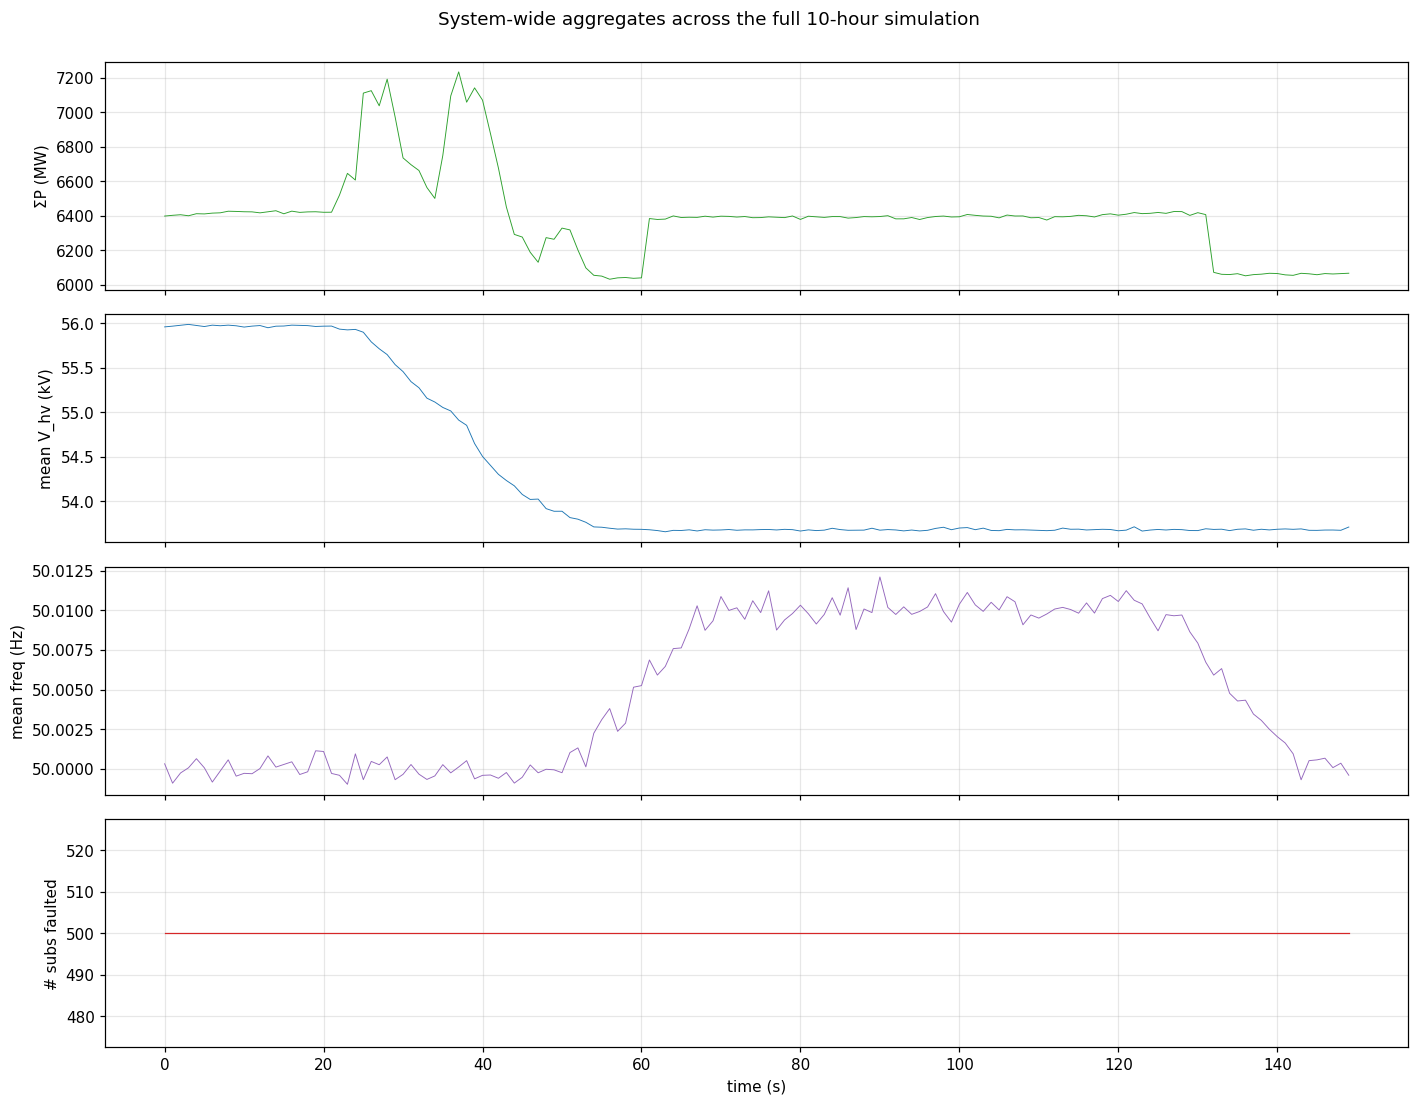

In [19]:

sys_ts = df.groupby('time_s').agg(
    total_P_MW=('P_MW','sum'),
    mean_V_hv=('V_hv_kV','mean'),
    mean_freq=('freq_Hz','mean'),
    n_faulted=('label', lambda s: (s!='normal').sum()),
).reset_index()

fig, axes = plt.subplots(4,1, figsize=(13,10), sharex=True)
axes[0].plot(sys_ts.time_s, sys_ts.total_P_MW, lw=.6, color='tab:green'); axes[0].set_ylabel('ΣP (MW)')
axes[1].plot(sys_ts.time_s, sys_ts.mean_V_hv, lw=.6, color='tab:blue');   axes[1].set_ylabel('mean V_hv (kV)')
axes[2].plot(sys_ts.time_s, sys_ts.mean_freq, lw=.6, color='tab:purple');axes[2].set_ylabel('mean freq (Hz)')
axes[3].plot(sys_ts.time_s, sys_ts.n_faulted, lw=.8, color='tab:red');   axes[3].set_ylabel('# subs faulted')
axes[3].set_xlabel('time (s)')
fig.suptitle('System-wide aggregates across the full 10-hour simulation', y=1.0)
plt.tight_layout(); plt.show()


**Fault co-occurrence** — how many substations fault simultaneously (system-wide vs. isolated events)?

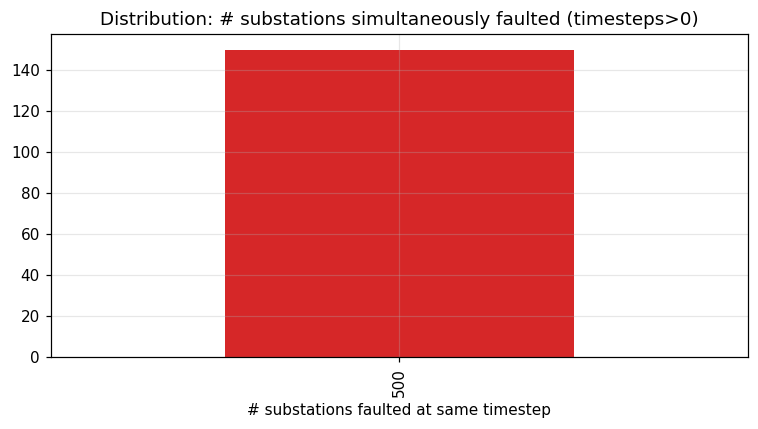

Max simultaneous faulted substations: 500


In [20]:

cooc = sys_ts.n_faulted.value_counts().sort_index()
cooc = cooc[cooc.index>0]
cooc.plot.bar(figsize=(7,4), color='tab:red', title='Distribution: # substations simultaneously faulted (timesteps>0)')
plt.xlabel('# substations faulted at same timestep'); plt.tight_layout(); plt.show()
print(f"Max simultaneous faulted substations: {sys_ts.n_faulted.max()}")


**Event timeline (Gantt / swimlane)** — every fault event across the whole dataset, one lane per substation, color-coded by fault type

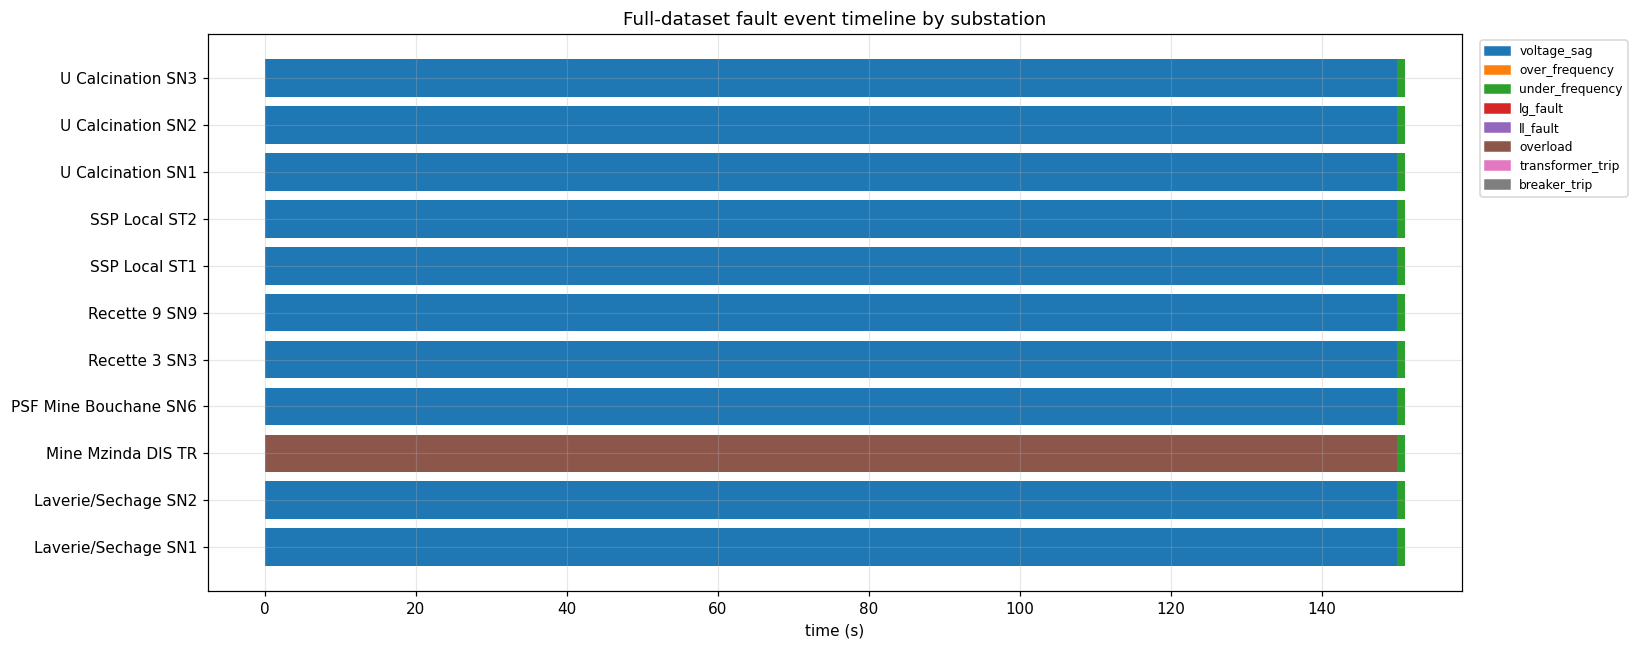

In [21]:

label_colors = dict(zip(LABELS[1:], plt.cm.tab10(np.linspace(0,1,10))))
fig, ax = plt.subplots(figsize=(15,6))
for i, sub in enumerate(SUBS):
    sub_events = events[events.substation==sub]
    bars = [(r.start, r.duration) for r in sub_events.itertuples()]
    colors = [label_colors[r.label] for r in sub_events.itertuples()]
    ax.broken_barh(bars, (i-.4, .8), facecolors=colors)
ax.set_yticks(range(len(SUBS))); ax.set_yticklabels(SUBS)
ax.set_xlabel('time (s)'); ax.set_title('Full-dataset fault event timeline by substation')
handles = [plt.Rectangle((0,0),1,1, color=c) for c in label_colors.values()]
ax.legend(handles, label_colors.keys(), bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 5. Per-Substation Full Time Series

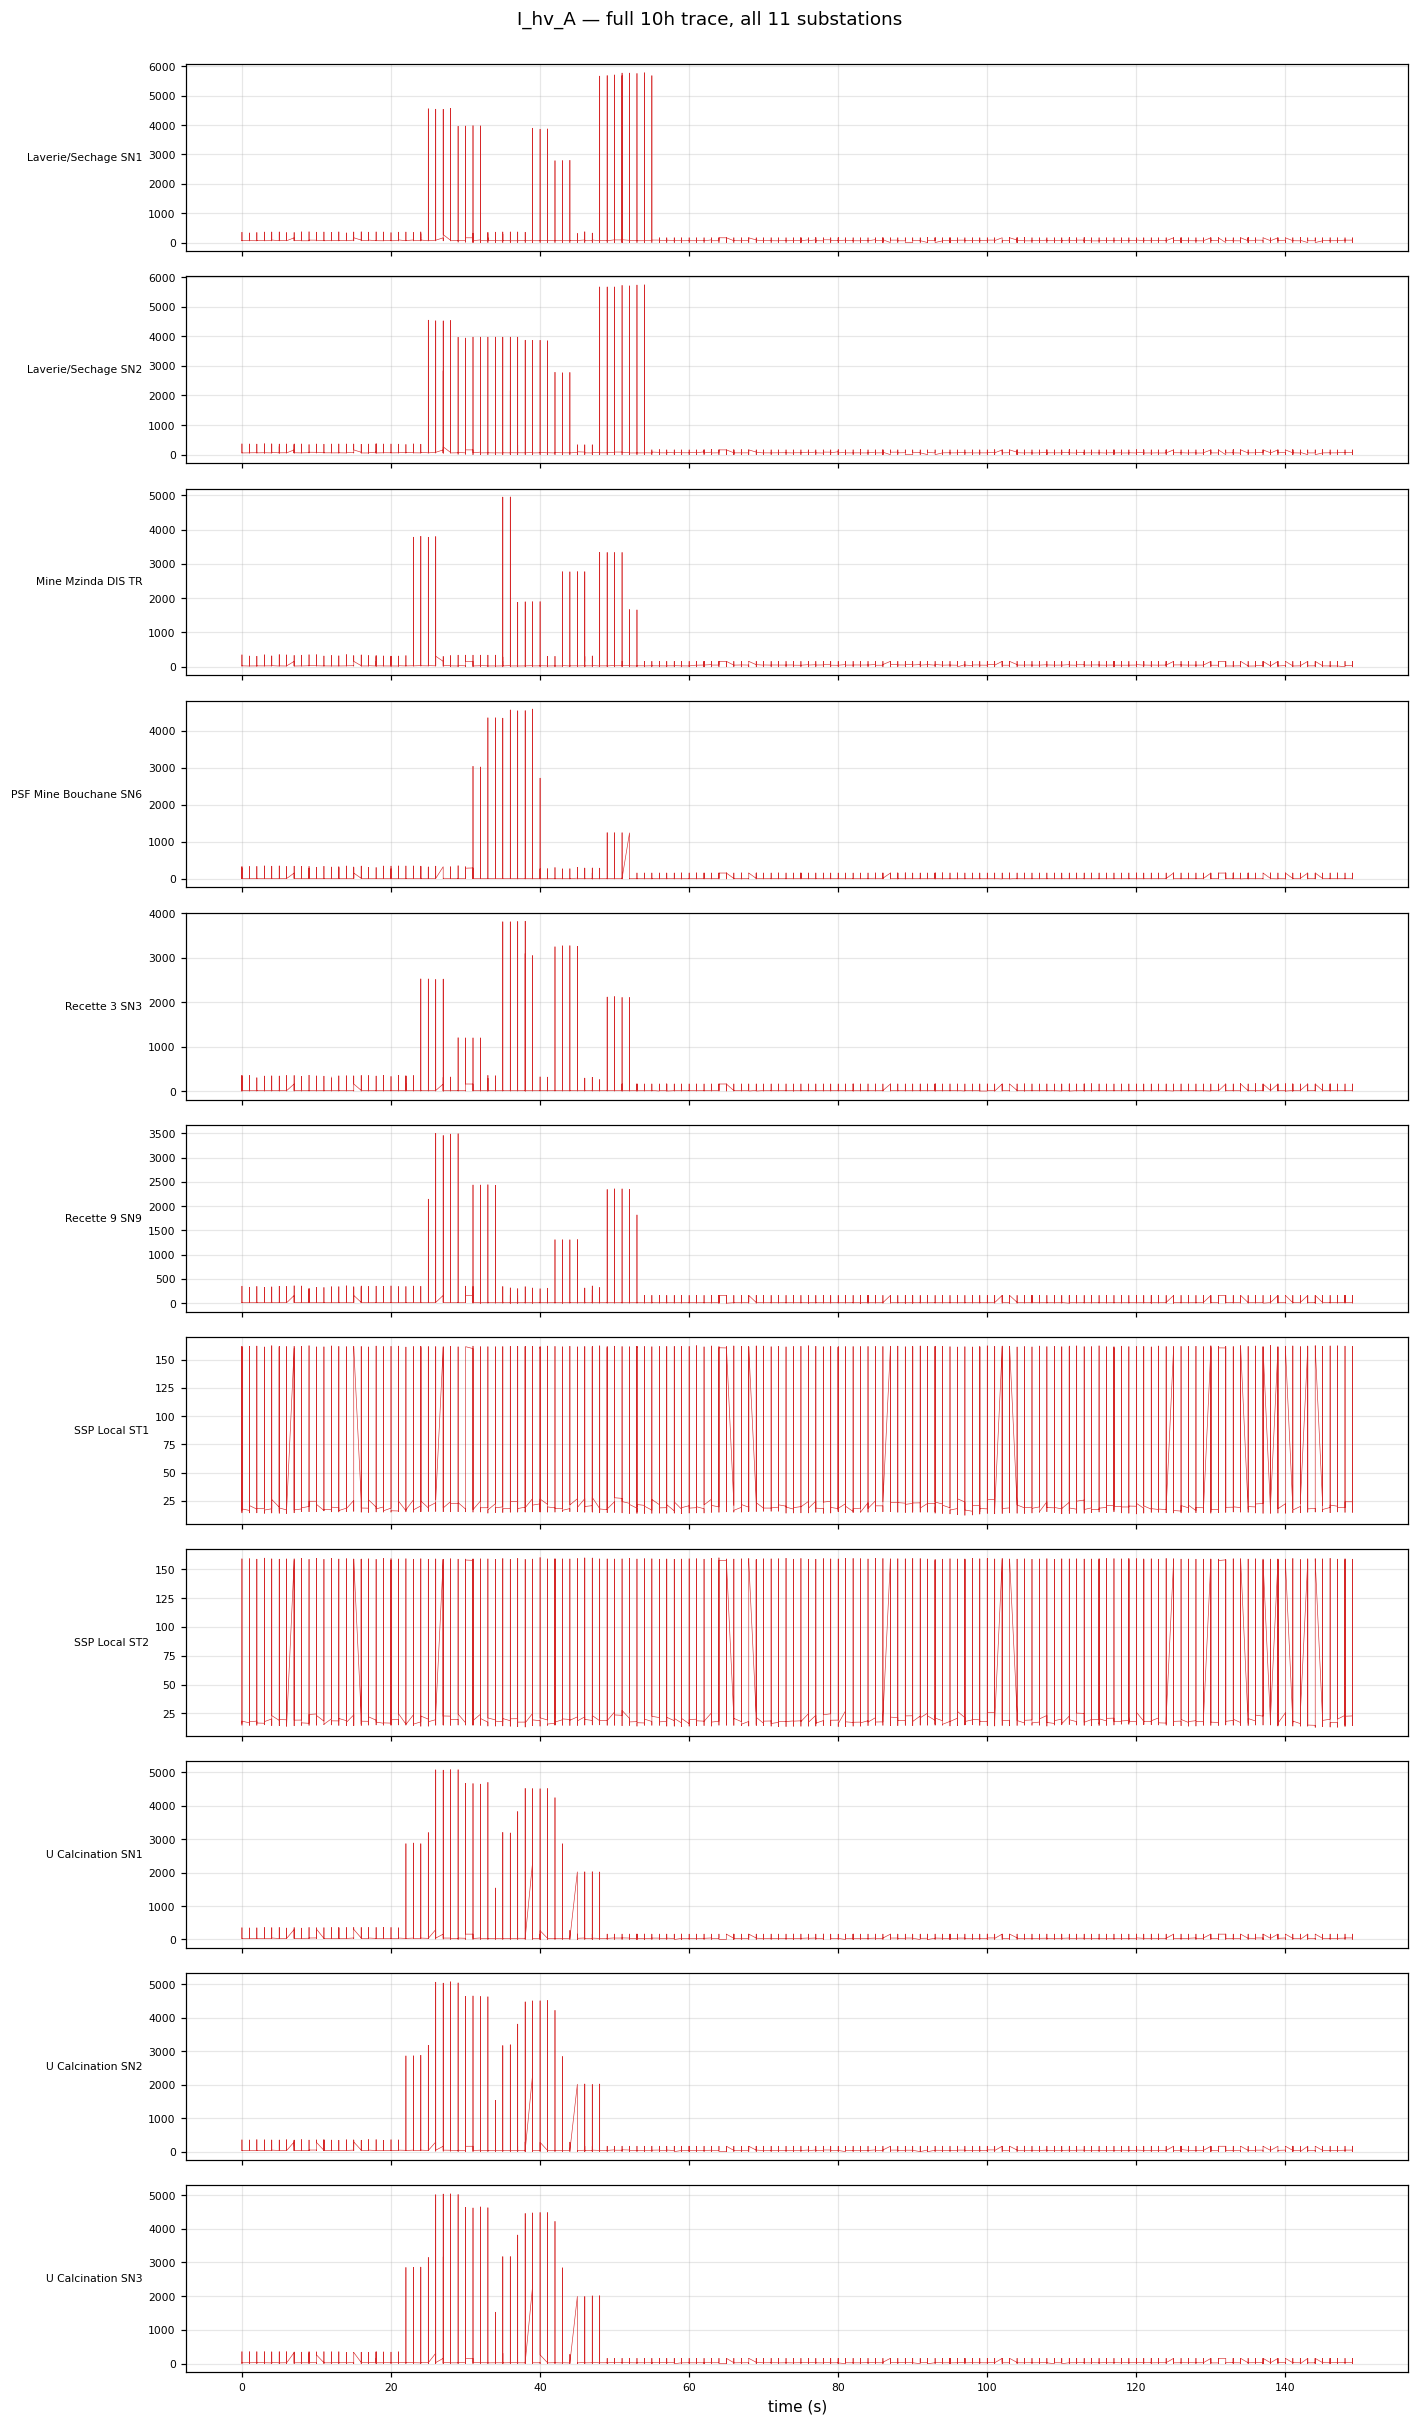

In [22]:

fig, axes = plt.subplots(len(SUBS), 1, figsize=(13, 2*len(SUBS)), sharex=True)
for ax, sub in zip(axes, SUBS):
    s = df[df.substation==sub].sort_values('time_s')
    ax.plot(s.time_s, s.I_hv_A, lw=.4, color='tab:red')
    ax.set_ylabel(sub, fontsize=7, rotation=0, ha='right', va='center')
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('time (s)')
fig.suptitle('I_hv_A — full 10h trace, all 11 substations', y=1.0)
plt.tight_layout(); plt.show()


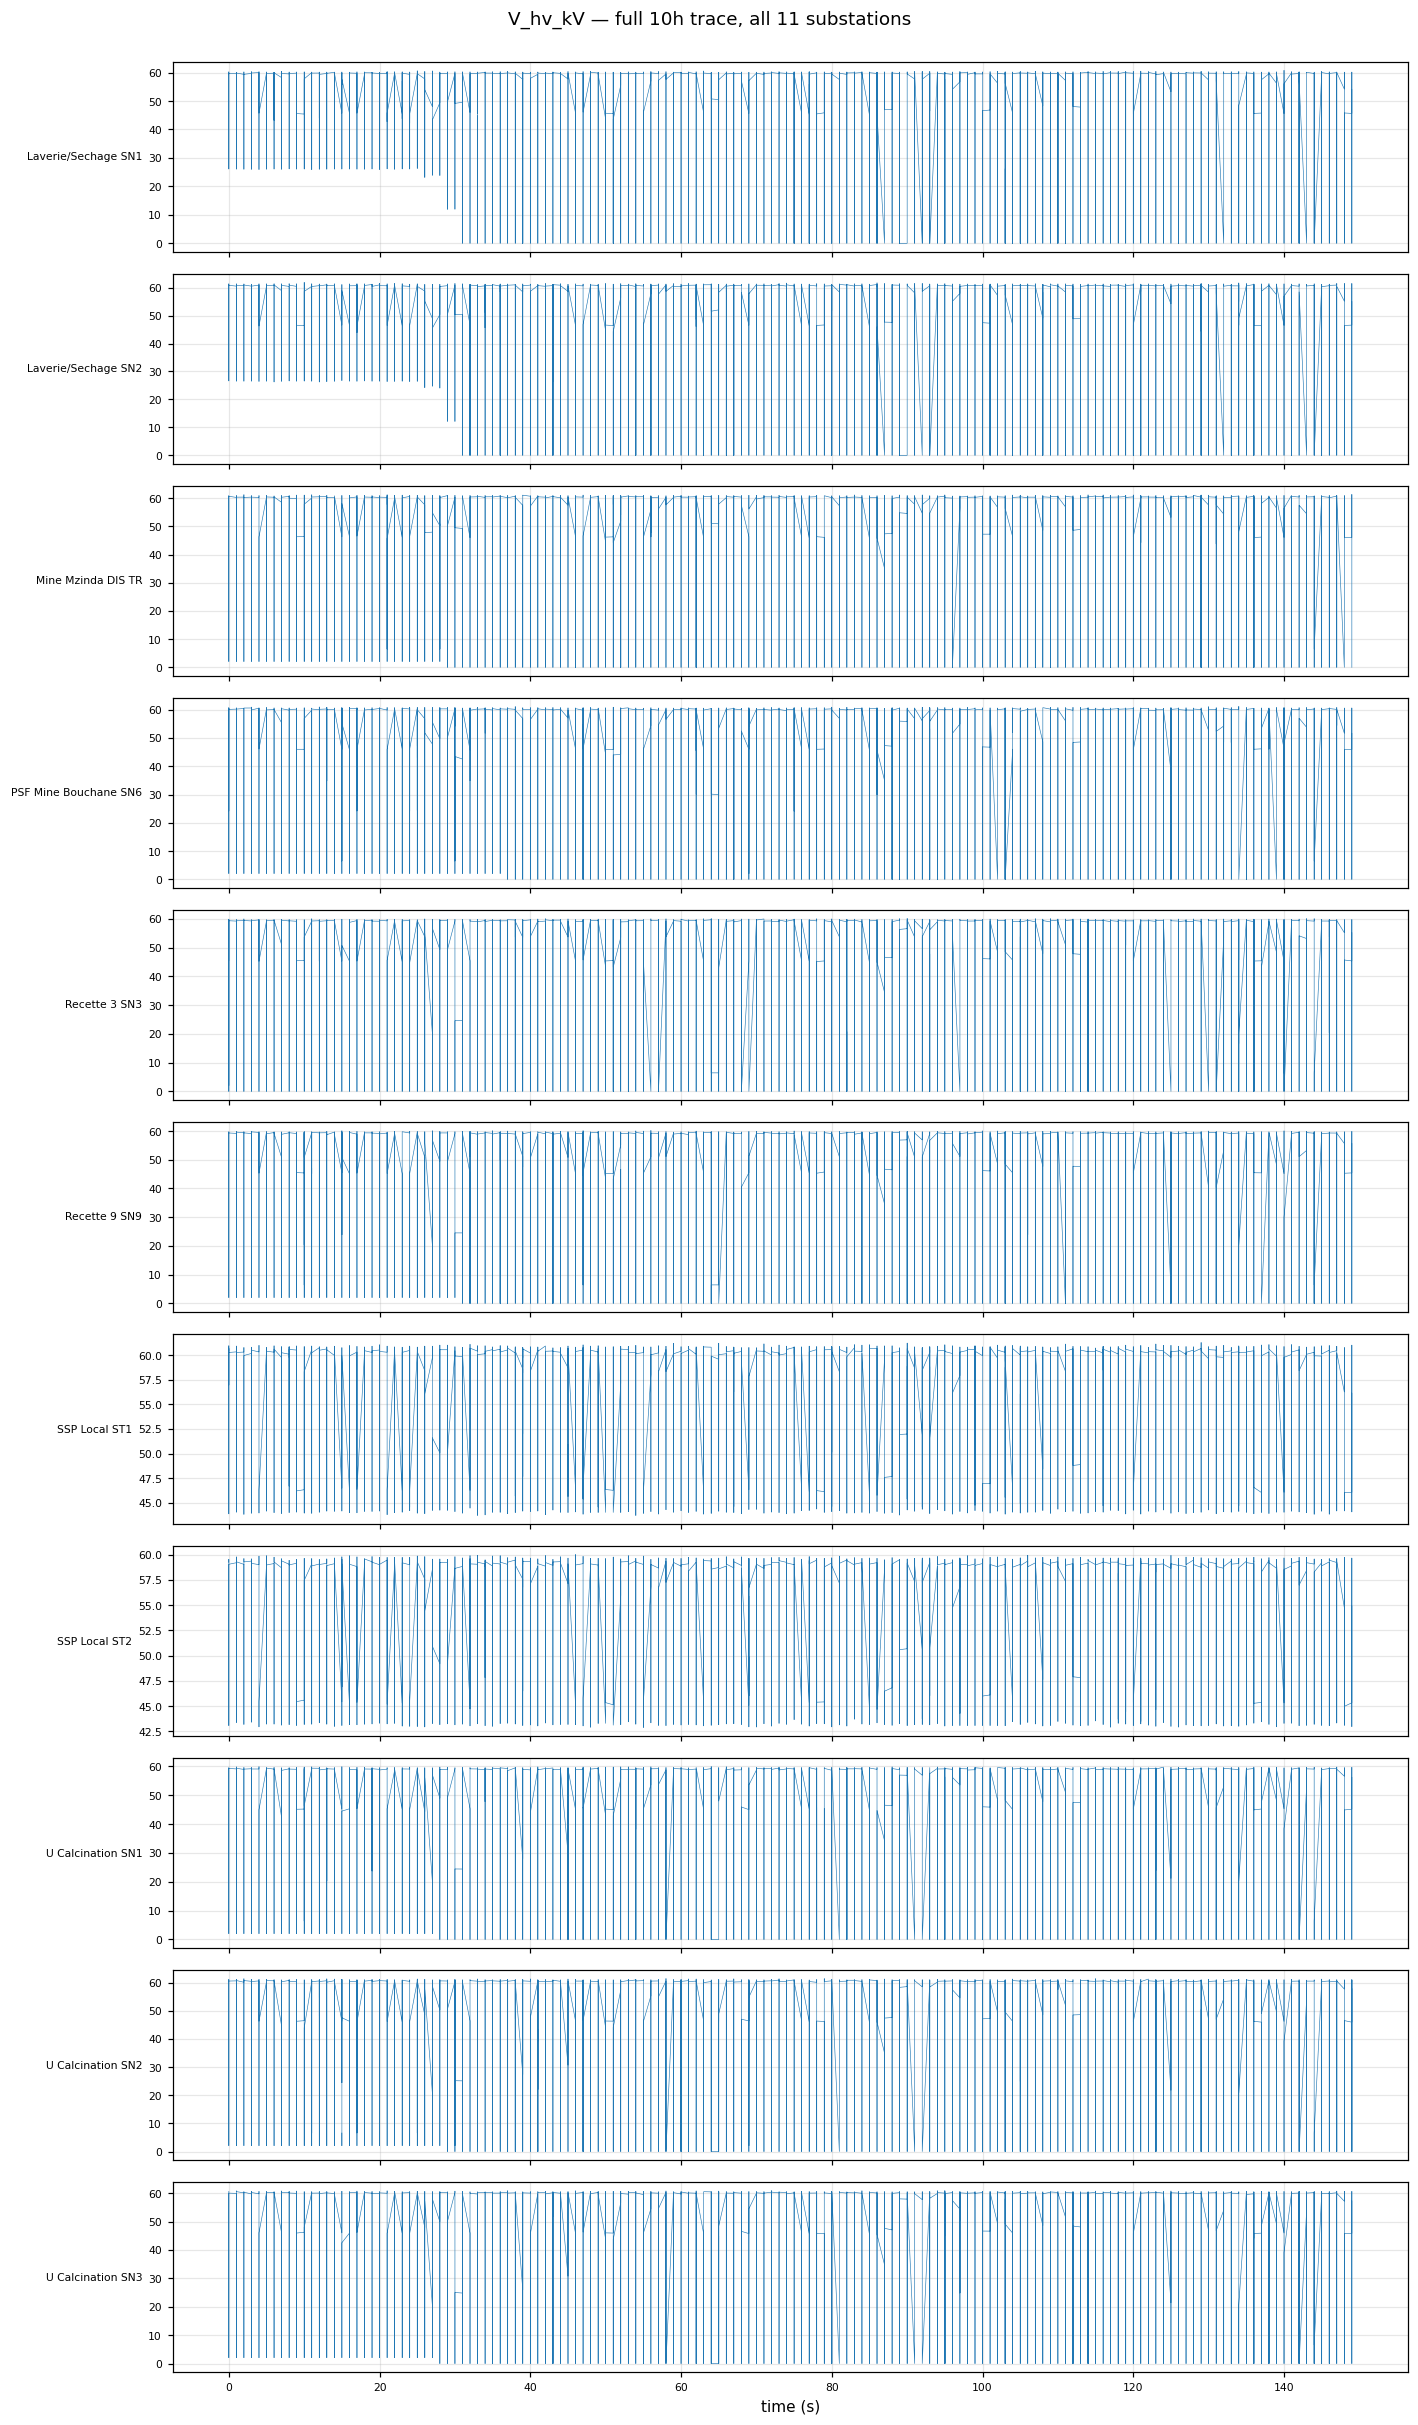

In [23]:

fig, axes = plt.subplots(len(SUBS), 1, figsize=(13, 2*len(SUBS)), sharex=True)
for ax, sub in zip(axes, SUBS):
    s = df[df.substation==sub].sort_values('time_s')
    ax.plot(s.time_s, s.V_hv_kV, lw=.4, color='tab:blue')
    ax.set_ylabel(sub, fontsize=7, rotation=0, ha='right', va='center')
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('time (s)')
fig.suptitle('V_hv_kV — full 10h trace, all 11 substations', y=1.0)
plt.tight_layout(); plt.show()


**Rolling statistics (60s window)** — trend/volatility check on one heavily-loaded substation

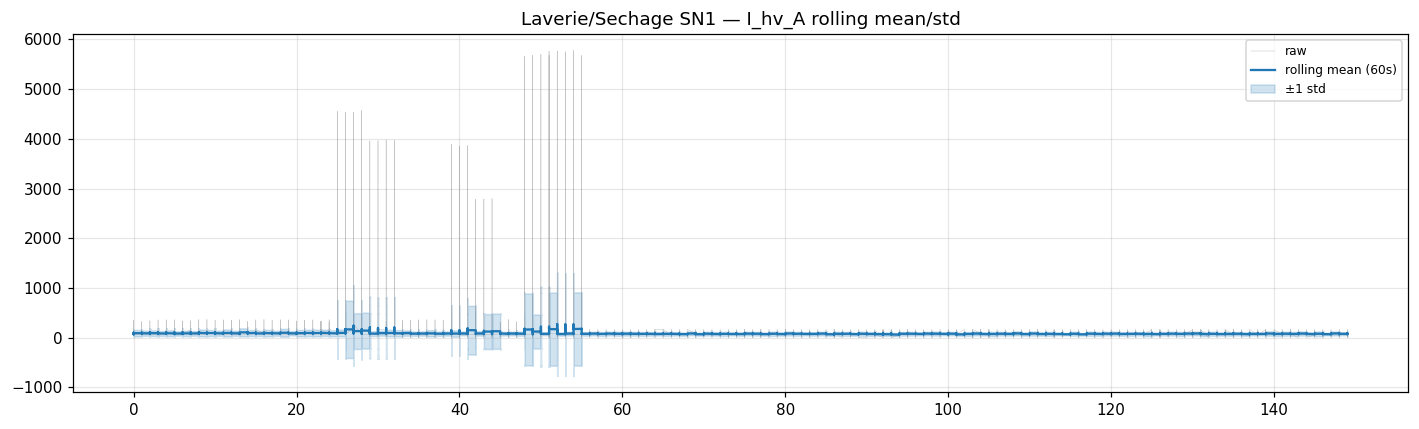

In [24]:

s = df[df.substation=="Laverie/Sechage SN1"].sort_values('time_s').set_index('time_s')
roll = s.I_hv_A.rolling(60, min_periods=1)
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(s.index, s.I_hv_A, lw=.3, color='gray', alpha=.5, label='raw')
ax.plot(s.index, roll.mean(), color='tab:blue', label='rolling mean (60s)')
ax.fill_between(s.index, roll.mean()-roll.std(), roll.mean()+roll.std(), color='tab:blue', alpha=.2, label='±1 std')
ax.set_title('Laverie/Sechage SN1 — I_hv_A rolling mean/std'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6. Zoomed Transients — One Example per Fault Type

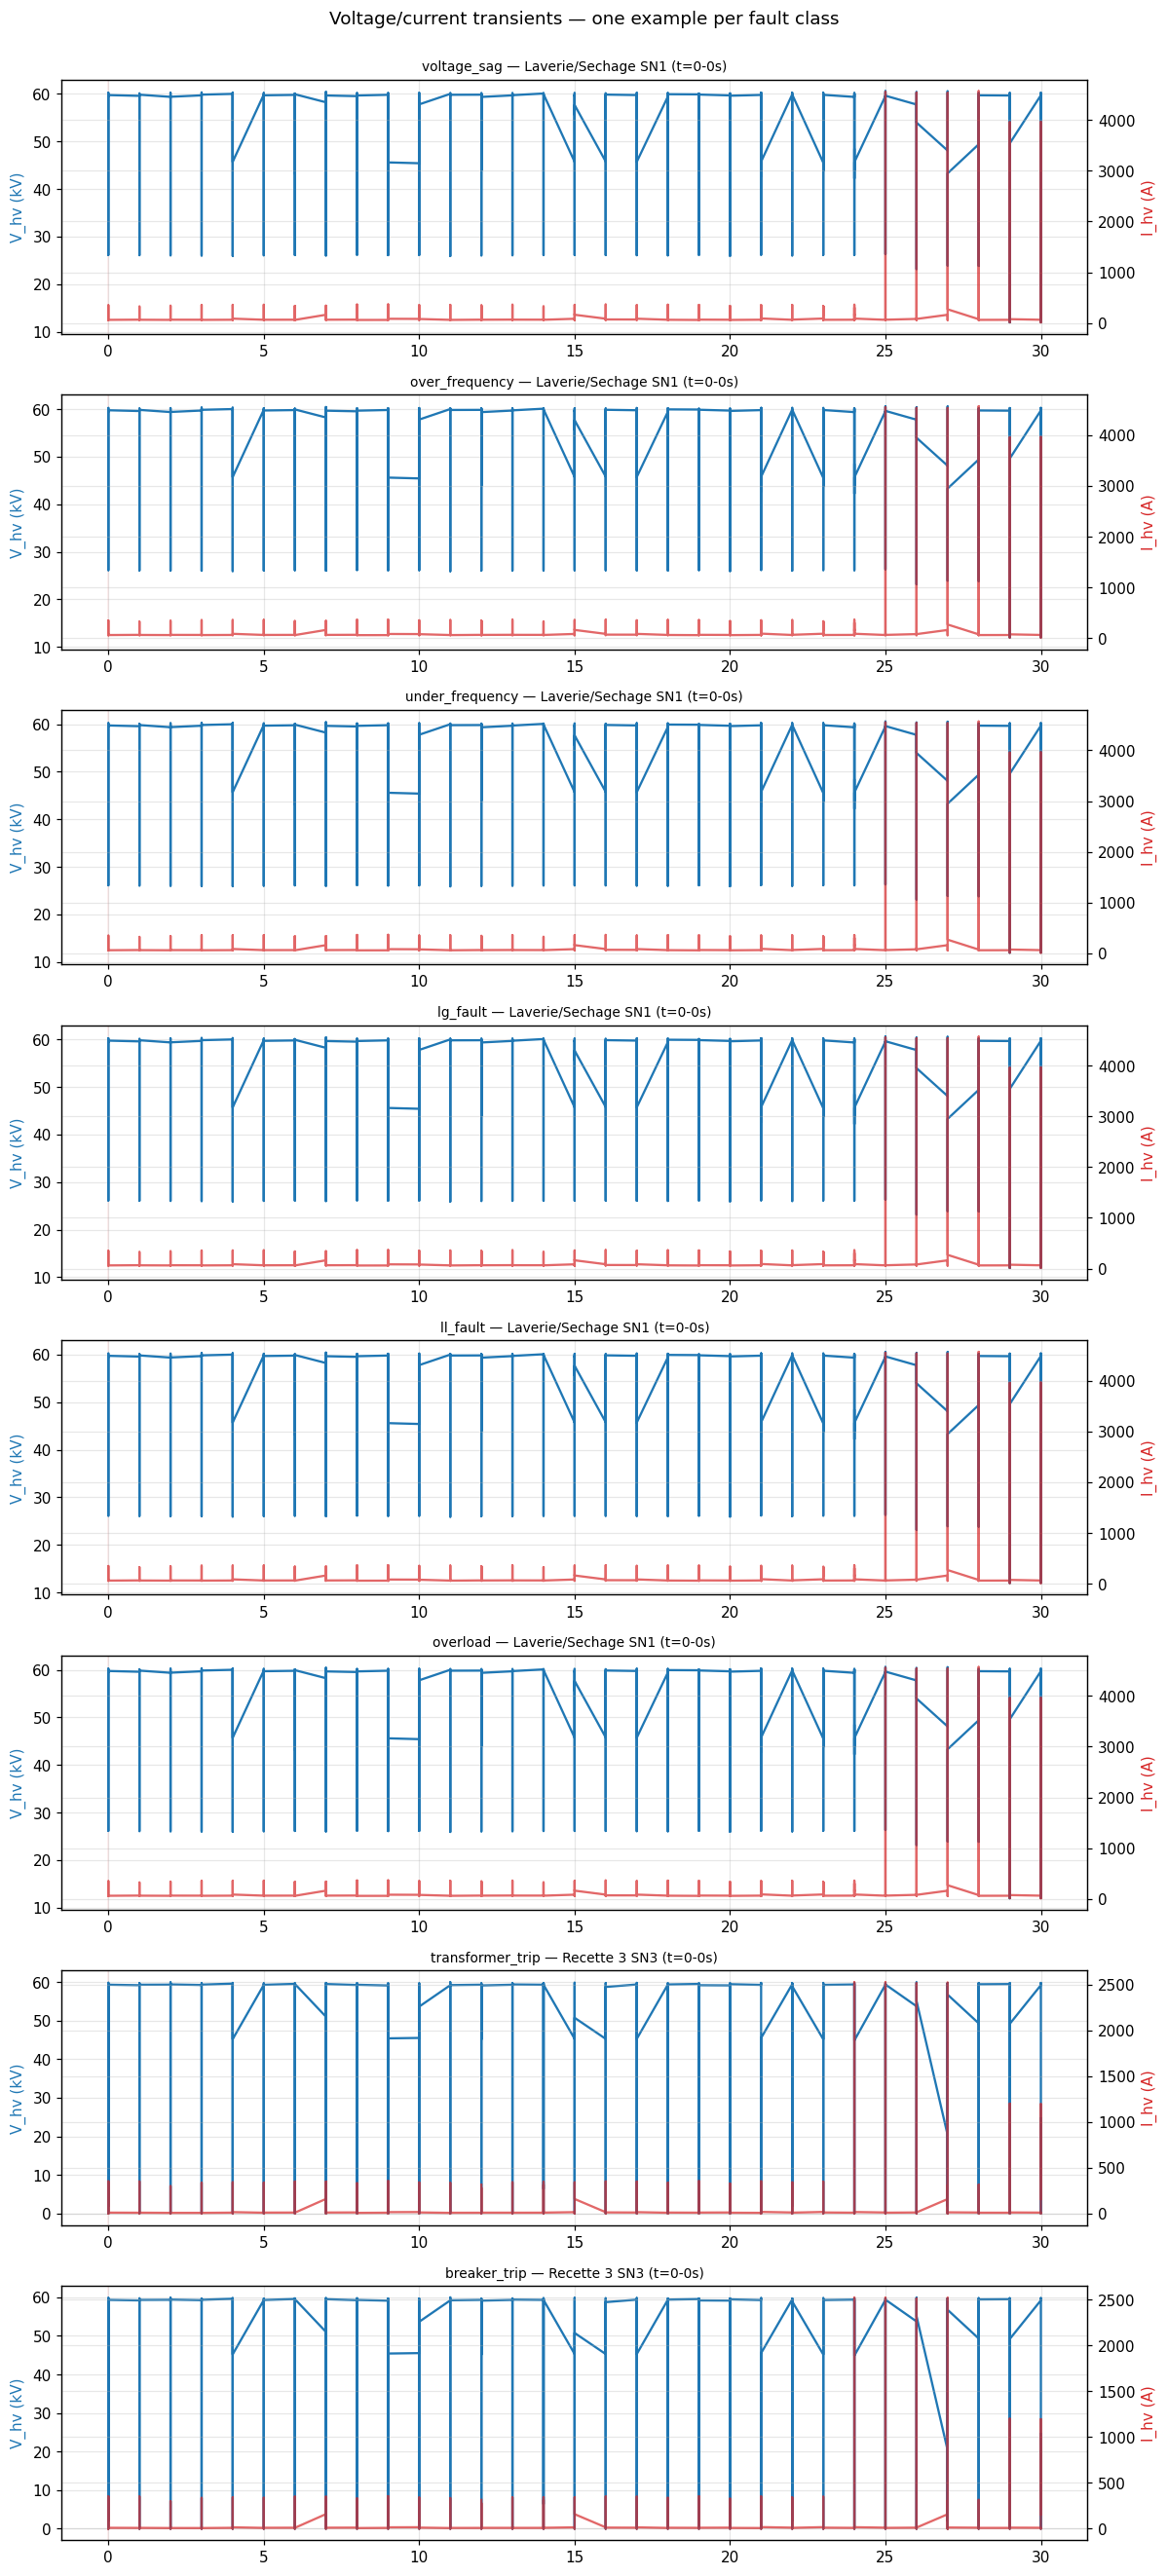

In [25]:

fault_types = [l for l in LABELS if l != 'normal']
fig, axes = plt.subplots(len(fault_types), 1, figsize=(11, 3*len(fault_types)))
for ax, ftype in zip(axes, fault_types):
    ev = events[events.label==ftype].iloc[0]
    s = df[df.substation==ev.substation].sort_values('time_s').reset_index(drop=True)
    lo, hi = max(0, ev.start-30), ev.end+30
    w = s[(s.time_s>=lo) & (s.time_s<=hi)]
    ax2 = ax.twinx()
    ax.plot(w.time_s, w.V_hv_kV, color='tab:blue', label='V_hv (kV)')
    ax2.plot(w.time_s, w.I_hv_A, color='tab:red', alpha=.7, label='I_hv (A)')
    ax.axvspan(ev.start, ev.end, color='red', alpha=.08)
    ax.set_ylabel('V_hv (kV)', color='tab:blue'); ax2.set_ylabel('I_hv (A)', color='tab:red')
    ax.set_title(f"{ftype} — {ev.substation} (t={ev.start}-{ev.end}s)", fontsize=9)
fig.suptitle('Voltage/current transients — one example per fault class', y=1.0)
plt.tight_layout(); plt.show()


## 7. Univariate Distributions

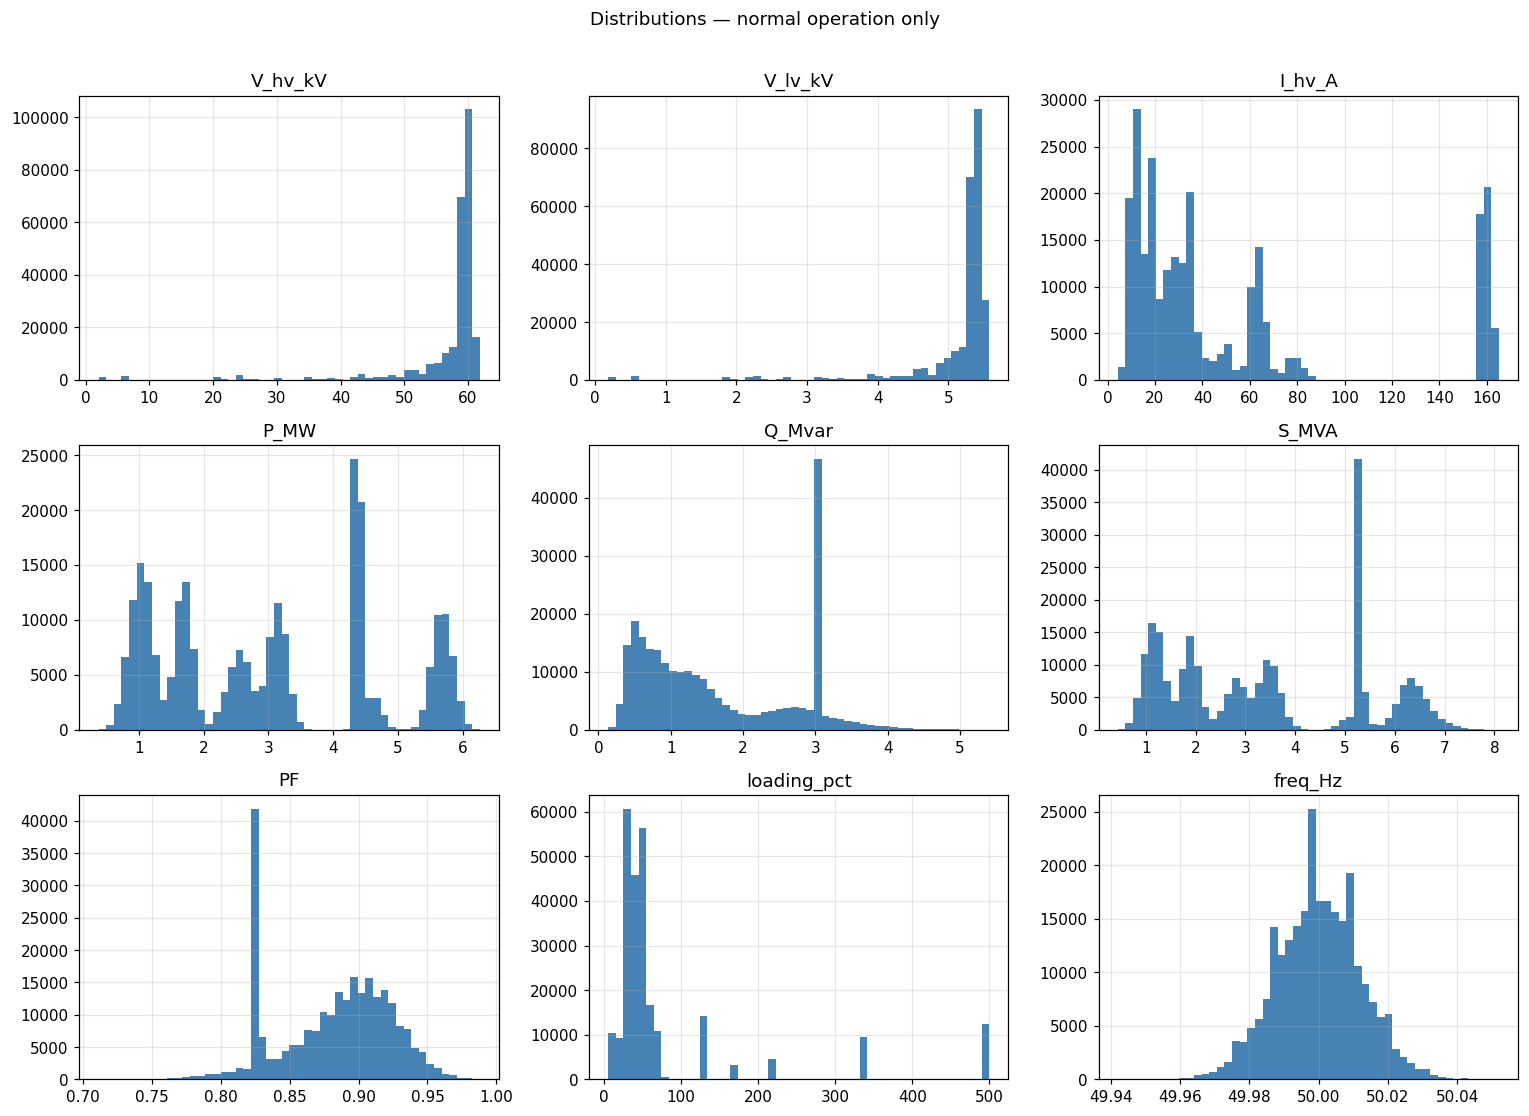

In [26]:

fig, axes = plt.subplots(3,3, figsize=(14,10))
for ax, col in zip(axes.flat, NUMERIC):
    df[df.label=='normal'][col].dropna().hist(ax=ax, bins=50, color='steelblue')
    ax.set_title(col)
fig.suptitle('Distributions — normal operation only', y=1.01)
plt.tight_layout(); plt.show()


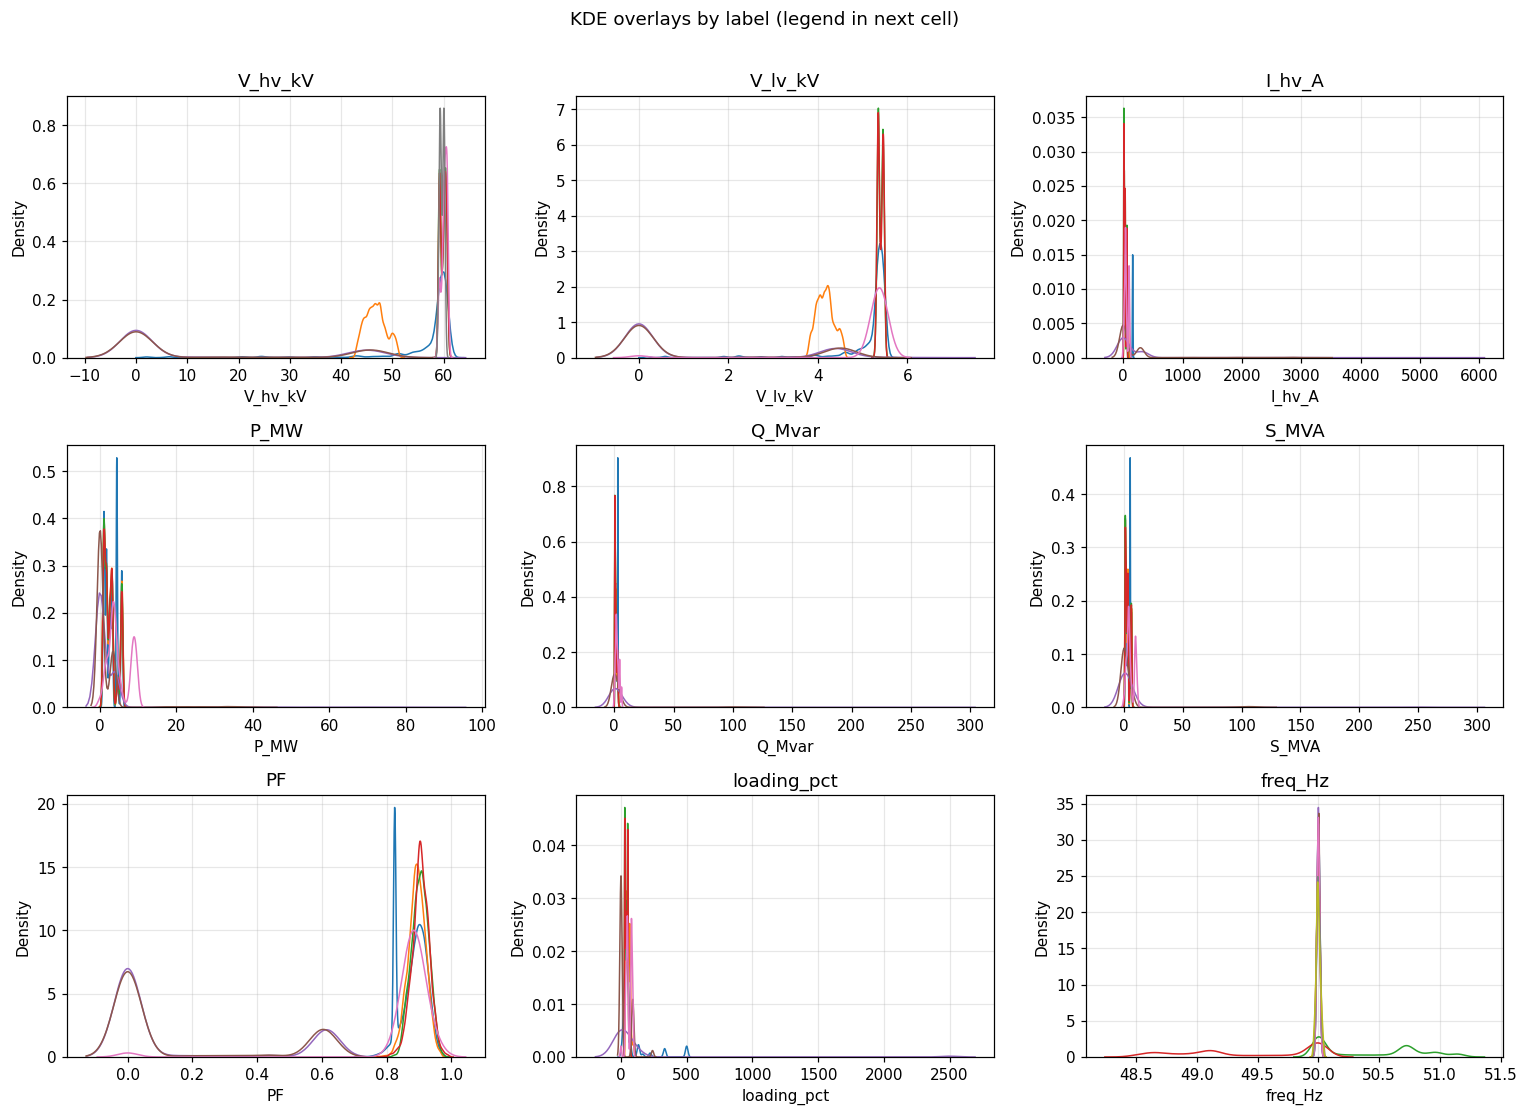

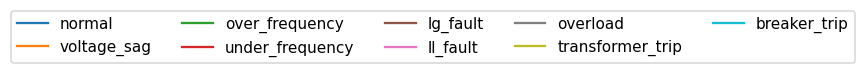

In [27]:

fig, axes = plt.subplots(3,3, figsize=(14,10))
for ax, col in zip(axes.flat, NUMERIC):
    for lab in LABELS:
        sns.kdeplot(df[df.label==lab][col].dropna(), ax=ax, label=lab, lw=1, warn_singular=False)
    ax.set_title(col); ax.legend([], [], frameon=False)
fig.suptitle('KDE overlays by label (legend in next cell)', y=1.01)
plt.tight_layout(); plt.show()
fig2 = plt.figure(figsize=(8,.5))
handles = [plt.Line2D([0],[0], color=c) for c in plt.cm.tab10(np.linspace(0,1,len(LABELS)))]
plt.figlegend(handles, LABELS, ncol=5, loc='center'); plt.axis('off'); plt.show()


## 8. Bivariate / Multivariate Relationships

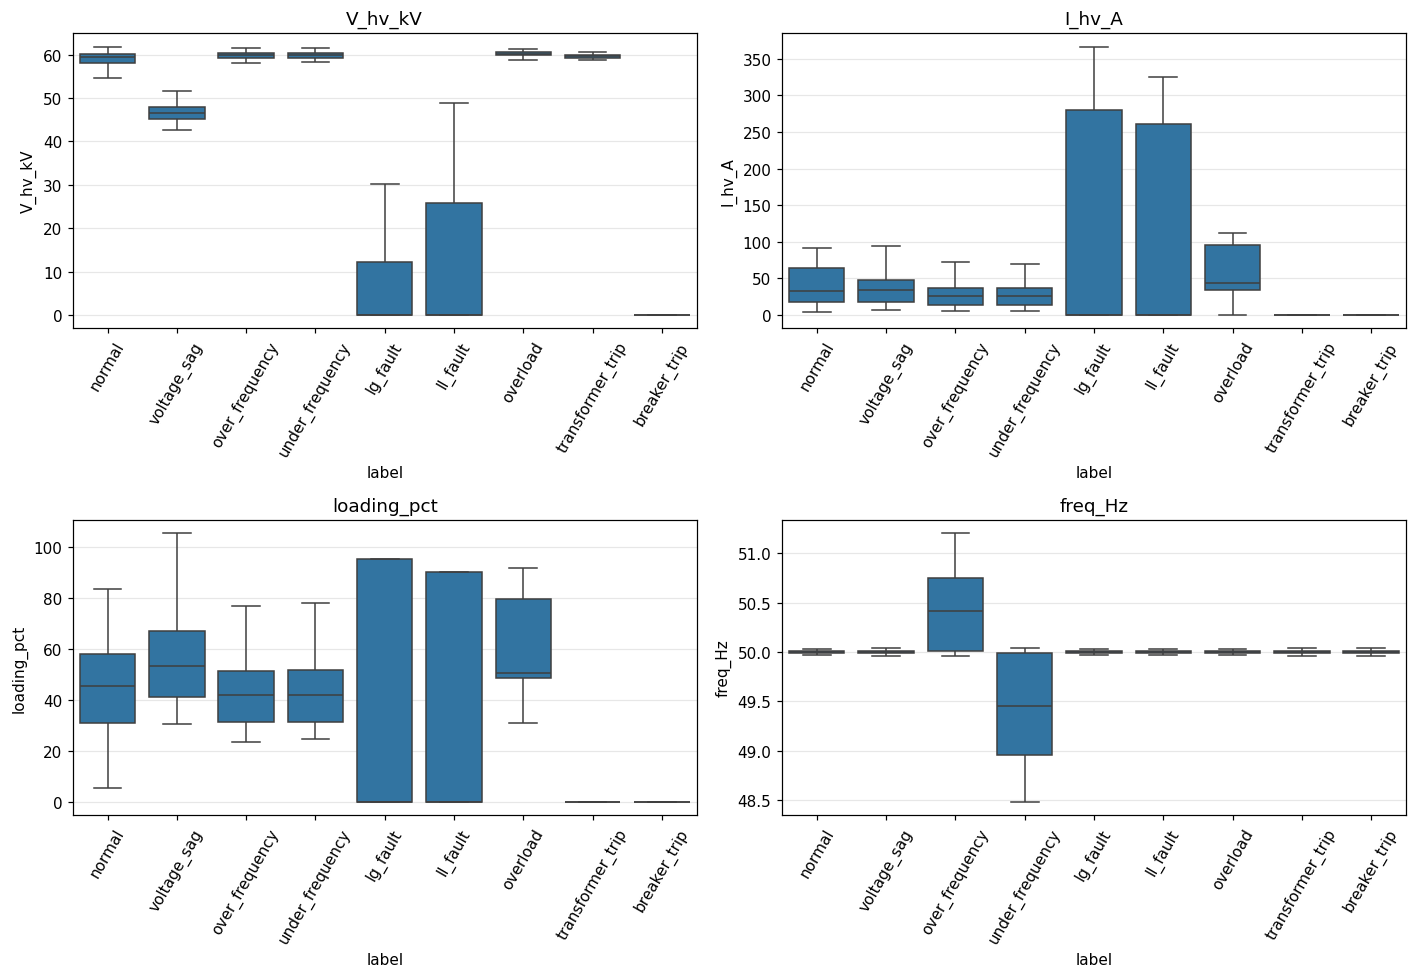

In [28]:

order = LABELS
fig, axes = plt.subplots(2,2, figsize=(13,9))
for ax, feat in zip(axes.flat, ['V_hv_kV','I_hv_A','loading_pct','freq_Hz']):
    sns.boxplot(data=df, x='label', y=feat, order=order, ax=ax, showfliers=False)
    ax.tick_params(axis='x', rotation=60); ax.set_title(feat)
plt.tight_layout(); plt.show()


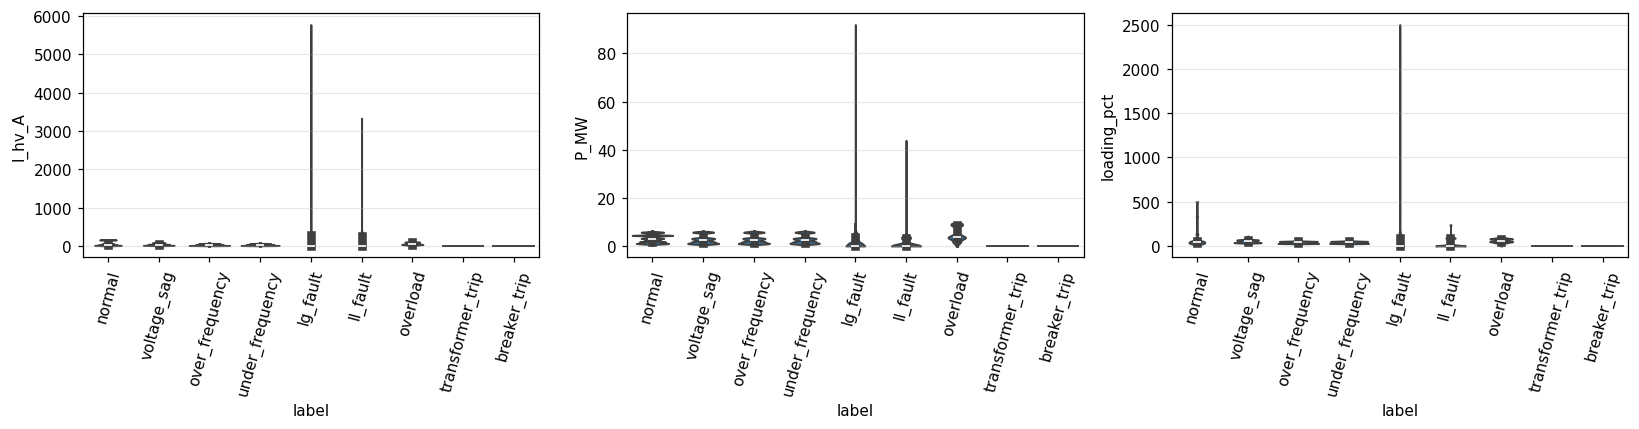

In [29]:

fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, ['I_hv_A','P_MW','loading_pct']):
    sns.violinplot(data=df, x='label', y=col, order=order, ax=ax, cut=0)
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout(); plt.show()


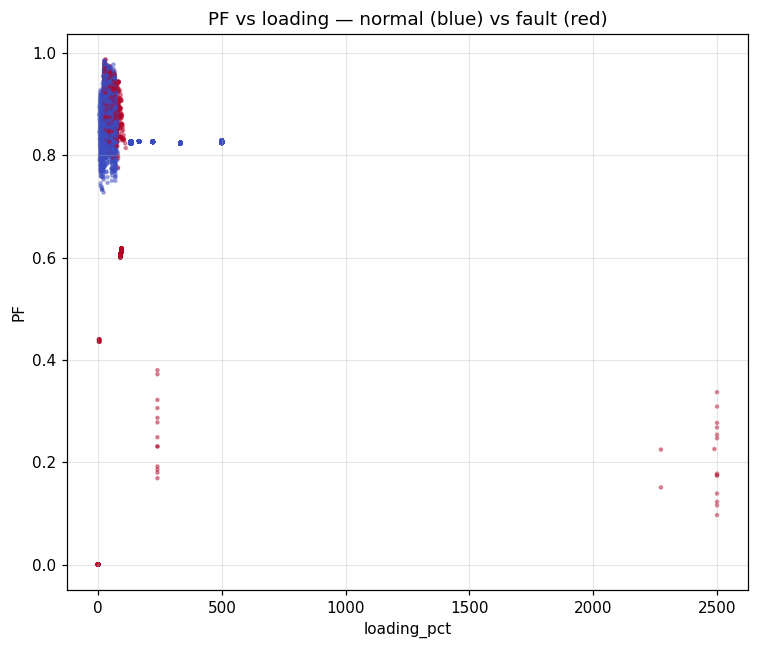

In [30]:

fig, ax = plt.subplots(figsize=(7,6))
samp = df.dropna(subset=['PF','loading_pct']).sample(20000, random_state=42)
sc = ax.scatter(samp.loading_pct, samp.PF, c=(samp.label!='normal'), cmap='coolwarm', s=4, alpha=.4)
ax.set_xlabel('loading_pct'); ax.set_ylabel('PF'); ax.set_title('PF vs loading — normal (blue) vs fault (red)')
plt.tight_layout(); plt.show()


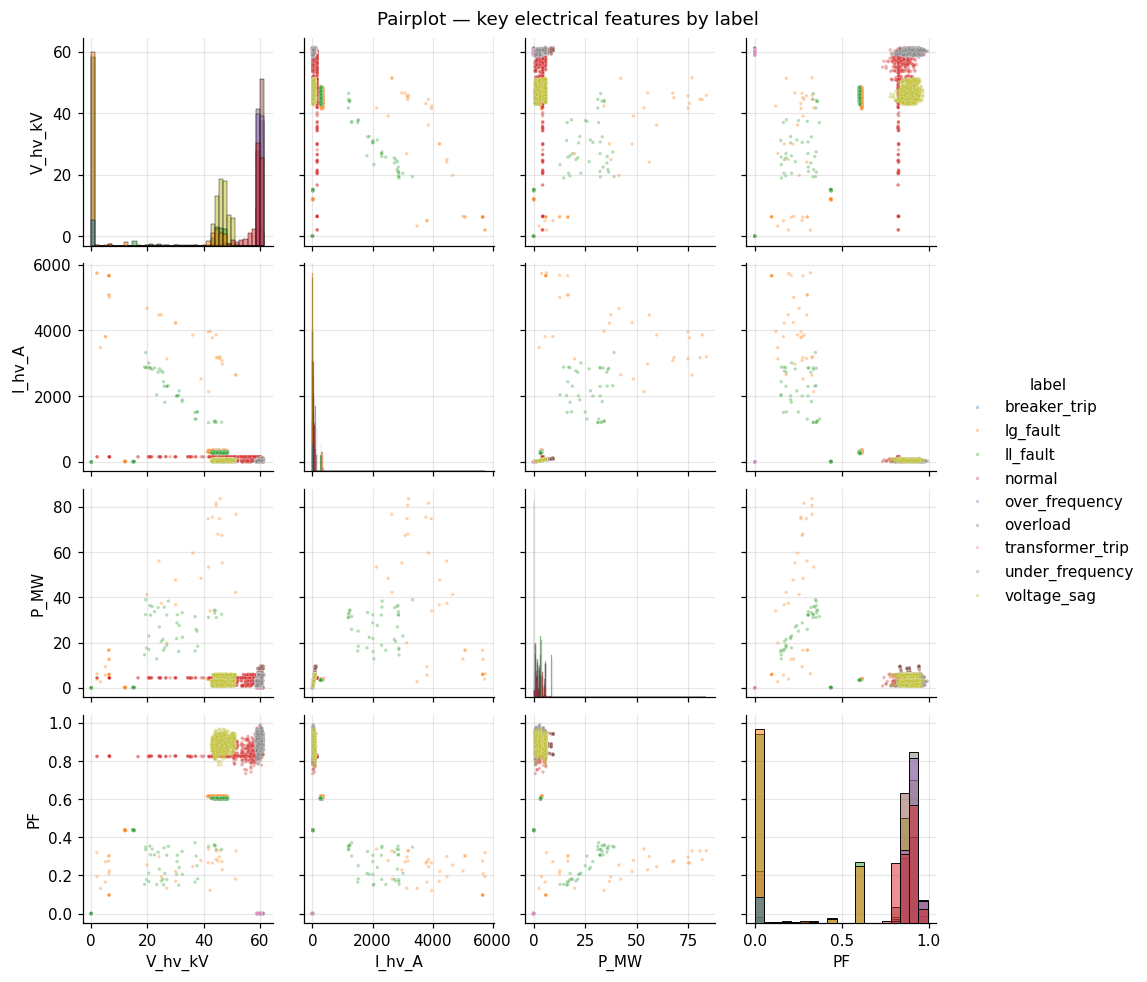

In [31]:

pair_cols = ['V_hv_kV','I_hv_A','P_MW','PF']
samp = pd.concat([g.sample(min(len(g),1500), random_state=42) for _, g in df.dropna(subset=pair_cols).groupby('label')])
g = sns.pairplot(samp, vars=pair_cols, hue='label', plot_kws=dict(s=5, alpha=.35), diag_kind='hist', height=2.2)
g.fig.suptitle('Pairplot — key electrical features by label', y=1.01)
plt.show()


## 9. Outlier Detection

In [32]:

def iqr_outliers(s, k=1.5):
    q1,q3 = s.quantile([.25,.75]); iqr = q3-q1
    return (s < q1-k*iqr) | (s > q3+k*iqr)

normal_num = df[df.label=='normal'][NUMERIC]
outlier_rate = normal_num.apply(lambda s: iqr_outliers(s.dropna()).mean()*100).round(2)
outlier_rate.to_frame('pct_outliers_IQR')


,pct_outliers_IQR
V_hv_kV,14.12
V_lv_kV,15.32
I_hv_A,17.24
P_MW,0.00
Q_Mvar,0.00
S_MVA,0.00
PF,0.03
loading_pct,17.24
freq_Hz,0.75


In [33]:

z = np.abs(stats.zscore(normal_num.dropna()))
zdf = pd.DataFrame(z, columns=NUMERIC)
print(f"rows with |z|>4 on any feature: {(zdf>4).any(axis=1).sum()} / {len(zdf)}")
(zdf>4).sum().to_frame('n_extreme_z')


rows with |z|>4 on any feature: 4707 / 254742


,n_extreme_z
V_hv_kV,4650
V_lv_kV,4667
I_hv_A,0
P_MW,0
Q_Mvar,0
S_MVA,0
PF,3
loading_pct,0
freq_Hz,29


In [34]:

from sklearn.ensemble import IsolationForest
X = normal_num.dropna()
iso = IsolationForest(contamination=0.01, random_state=42).fit(X)
pred = iso.predict(X)
print(f"IsolationForest flags {np.sum(pred==-1)} / {len(X)} normal-labeled rows as anomalous ({np.mean(pred==-1)*100:.2f}%)")
X.assign(anomaly=pred).query('anomaly==-1').describe().T[['mean','min','max']]


IsolationForest flags 2547 / 254742 normal-labeled rows as anomalous (1.00%)


,mean,min,max
V_hv_kV,6.697800,2.011,58.949
V_lv_kV,0.611058,0.184,5.254
I_hv_A,157.379584,79.220,161.470
P_MW,4.410584,4.347,6.140
Q_Mvar,3.033052,3.000,5.352
S_MVA,5.353517,5.282,8.090
PF,0.824384,0.734,0.828
loading_pct,373.063117,65.160,500.000
freq_Hz,50.000222,49.951,50.044
anomaly,-1.000000,-1.000,-1.000


## 10. Correlation, Multicollinearity & Statistical Separation

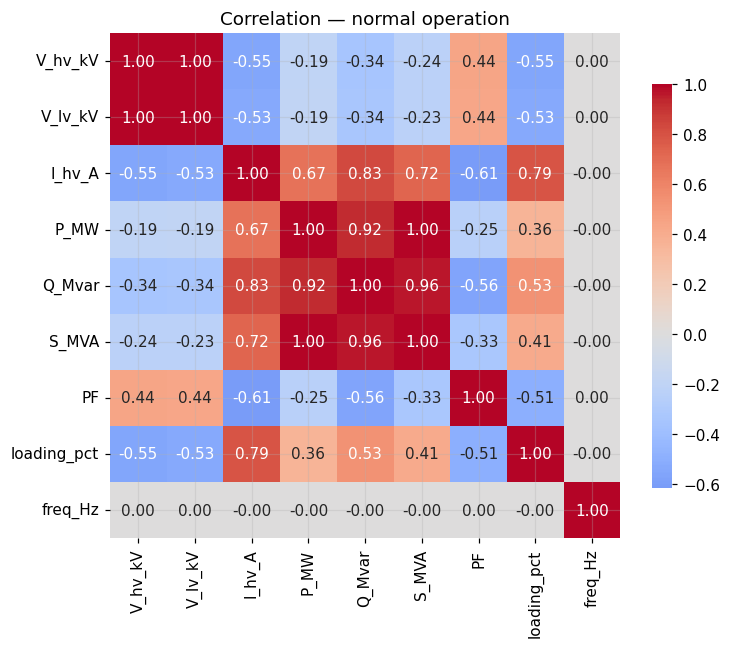

In [35]:

corr = df[df.label=='normal'][NUMERIC].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink':.8})
ax.set_title('Correlation — normal operation')
plt.tight_layout(); plt.show()


In [36]:

from sklearn.linear_model import LinearRegression
def vif(frame):
    out = {}
    for c in frame.columns:
        X = frame.drop(columns=[c]); y = frame[c]
        r2 = LinearRegression().fit(X,y).score(X,y)
        out[c] = 1/(1-r2) if r2 < 1 else np.inf
    return pd.Series(out)

vif(normal_num.dropna()).sort_values(ascending=False).to_frame('VIF')


,VIF
S_MVA,16232.300676
P_MW,9437.454467
Q_Mvar,1057.152364
V_hv_kV,575.655701
V_lv_kV,550.692186
I_hv_A,12.157568
PF,5.926763
loading_pct,3.254564
freq_Hz,1.000156


**Kolmogorov–Smirnov test** — is each feature's distribution significantly different between `normal` and each fault class? (signal for feature importance)

In [37]:

ks_results = {}
normal_vals = {c: df[df.label=='normal'][c].dropna() for c in NUMERIC}
for lab in LABELS:
    if lab == 'normal': continue
    row = {}
    for c in NUMERIC:
        fault_vals = df[df.label==lab][c].dropna()
        if len(fault_vals) > 5:
            stat, p = stats.ks_2samp(normal_vals[c], fault_vals)
            row[c] = stat  # KS statistic: 0=identical, 1=fully separated
    ks_results[lab] = row
ks_df = pd.DataFrame(ks_results).T.round(3)
ks_df.style.background_gradient(cmap='RdYlGn', axis=None)


,V_hv_kV,V_lv_kV,I_hv_A,P_MW,Q_Mvar,S_MVA,PF,loading_pct,freq_Hz
voltage_sag,0.902000,0.909000,0.172000,0.136000,0.144000,0.137000,0.211000,0.272000,0.058000
over_frequency,0.287000,0.261000,0.201000,0.135000,0.187000,0.152000,0.251000,0.183000,0.624000
under_frequency,0.288000,0.262000,0.203000,0.136000,0.197000,0.150000,0.268000,0.180000,0.627000
lg_fault,0.922000,0.880000,0.734000,0.747000,0.746000,0.747000,1.000000,0.747000,0.010000
ll_fault,0.925000,0.887000,0.725000,0.739000,0.739000,0.739000,1.000000,0.739000,0.010000
overload,0.377000,0.216000,0.353000,0.371000,0.385000,0.382000,0.226000,0.326000,0.024000
transformer_trip,0.317000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.086000
breaker_trip,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.122000


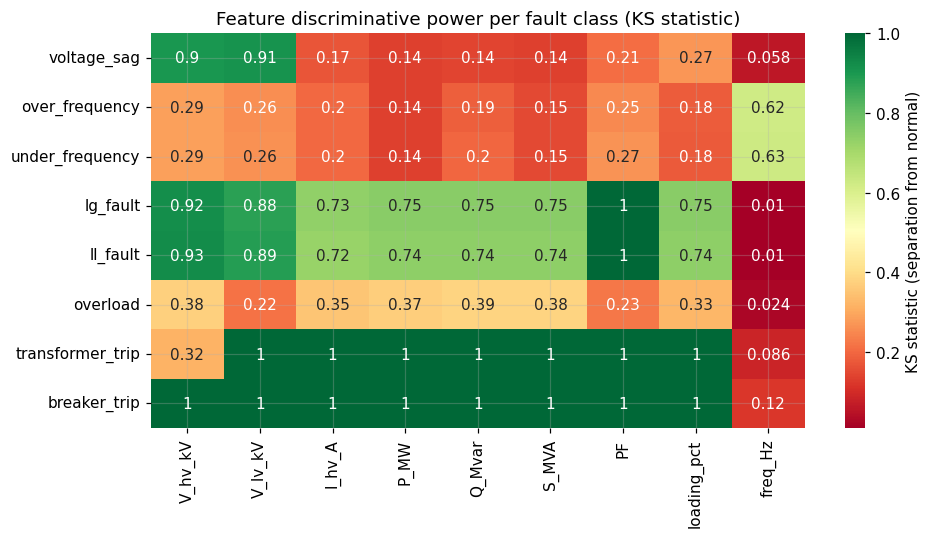

In [38]:

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(ks_df, annot=True, cmap='RdYlGn', ax=ax, cbar_kws={'label':'KS statistic (separation from normal)'})
ax.set_title('Feature discriminative power per fault class (KS statistic)')
plt.tight_layout(); plt.show()


## 11. Time-Series Diagnostics (stationarity, autocorrelation)

In [39]:

s = df[df.substation=="Laverie/Sechage SN1"].sort_values('time_s')
normal_segment = s[s.label=='normal'].I_hv_A.dropna()
adf_stat, adf_p, *_ = adfuller(normal_segment)
print(f"ADF test on I_hv_A (normal segment): stat={adf_stat:.3f}, p-value={adf_p:.4f}")
print("→ stationary (reject unit root)" if adf_p < 0.05 else "→ non-stationary")


ADF test on I_hv_A (normal segment): stat=-152.022, p-value=0.0000
→ stationary (reject unit root)


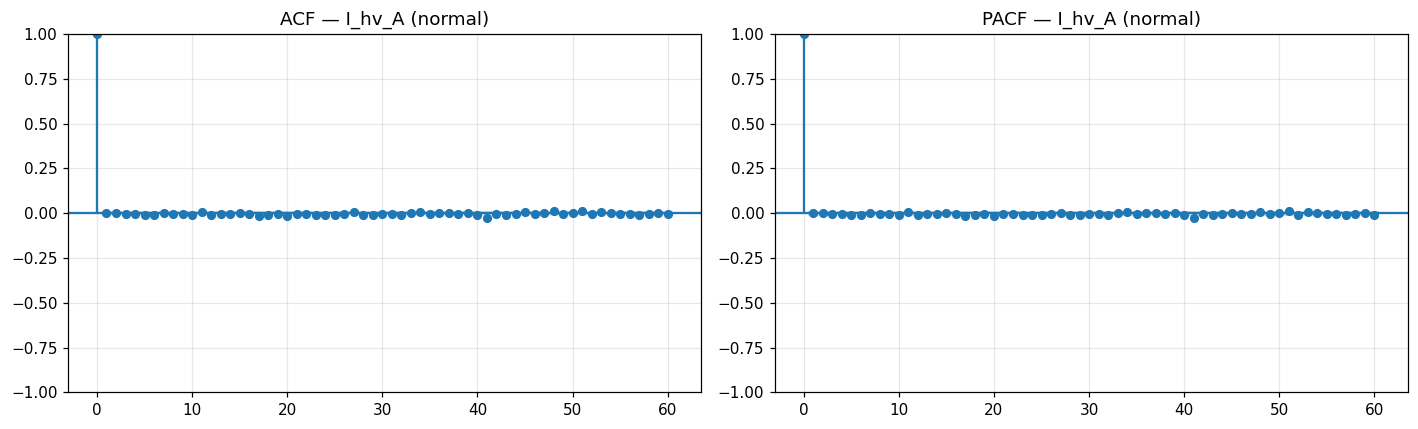

In [40]:

fig, axes = plt.subplots(1,2, figsize=(13,4))
plot_acf(normal_segment, lags=60, ax=axes[0]); axes[0].set_title('ACF — I_hv_A (normal)')
plot_pacf(normal_segment, lags=60, ax=axes[1], method='ywm'); axes[1].set_title('PACF — I_hv_A (normal)')
plt.tight_layout(); plt.show()


## 12. Per-Substation Profile Summary

In [41]:

prof = df.groupby('substation').agg(
    n_fault_steps=('label', lambda s: (s!='normal').sum()),
    fault_rate_pct=('label', lambda s: (s!='normal').mean()*100),
    mean_loading=('loading_pct','mean'),
    mean_I_hv=('I_hv_A','mean'),
    mean_V_hv=('V_hv_kV','mean'),
    std_V_hv=('V_hv_kV','std'),
).sort_values('n_fault_steps', ascending=False).round(2)
prof


,n_fault_steps,fault_rate_pct,mean_loading,mean_I_hv,mean_V_hv,std_V_hv
substation,,,,,,
U Calcination SN3,8700,29.0,47.84,55.88,51.12,17.55
U Calcination SN1,8400,28.0,43.43,60.56,50.28,17.27
U Calcination SN2,8400,28.0,43.93,60.97,51.52,17.69
Laverie/Sechage SN2,7050,23.5,65.77,84.91,56.31,11.88
Laverie/Sechage SN1,6750,22.5,66.74,86.24,55.35,11.69
Recette 3 SN3,6600,22.0,106.82,34.72,52.52,13.77
Mine Mzinda DIS TR,6450,21.5,76.88,61.05,55.96,11.31
Recette 9 SN9,6300,21.0,107.63,37.01,52.16,14.17
PSF Mine Bouchane SN6,6150,20.5,111.87,37.89,54.84,11.54


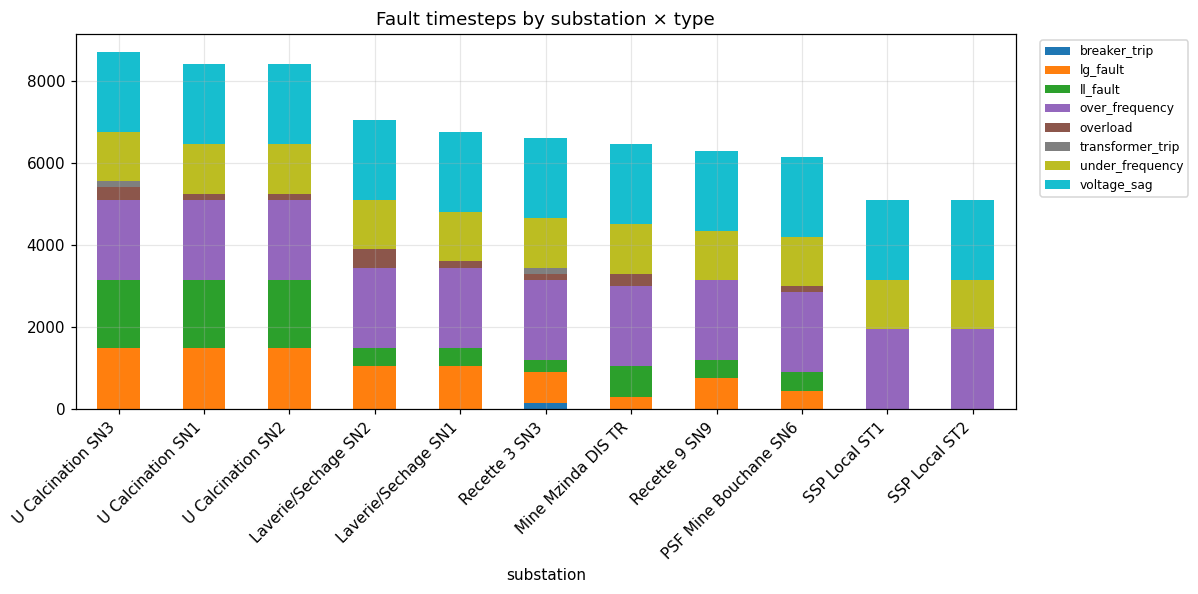

In [42]:

fault_df = df[df.label!='normal']
pivot = fault_df.groupby(['substation','label']).size().unstack(fill_value=0)
pivot = pivot.loc[pivot.sum(1).sort_values(ascending=False).index]
pivot.plot(kind='bar', stacked=True, figsize=(11,5.5), colormap='tab10')
plt.title('Fault timesteps by substation × type'); plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 13. Class Separability (PCA / t-SNE)

explained variance ratio: [0.472 0.314]


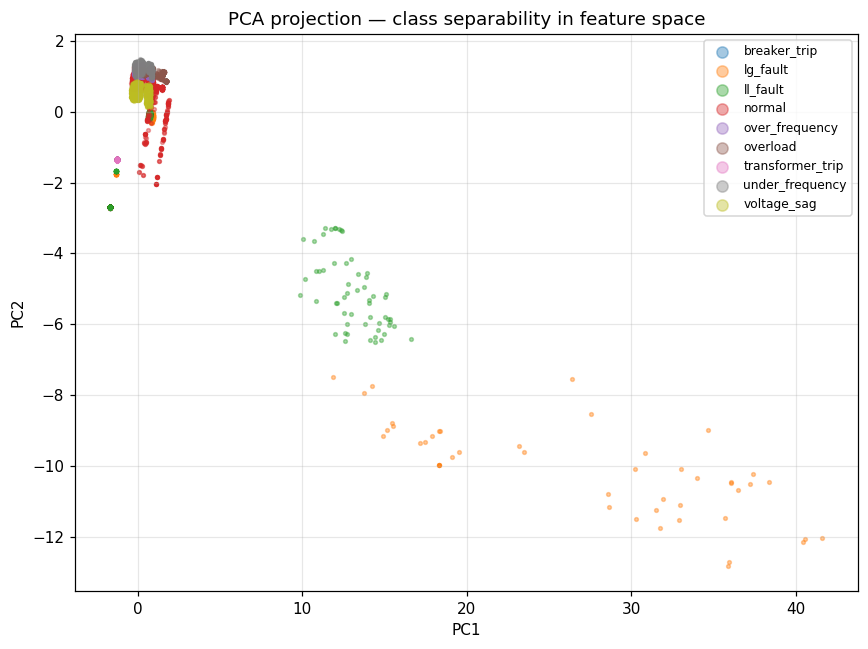

In [43]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

clean = df.dropna(subset=NUMERIC)
samp = pd.concat([
    g.sample(min(len(g), 2000), random_state=42) for _, g in clean.groupby('label')
]).reset_index(drop=True)
X = StandardScaler().fit_transform(samp[NUMERIC])
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
print('explained variance ratio:', pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(8,6))
for lab in samp.label.unique():
    m = samp.label.values == lab
    ax.scatter(pcs[m,0], pcs[m,1], s=6, alpha=.4, label=lab)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(markerscale=3, fontsize=8)
ax.set_title('PCA projection — class separability in feature space')
plt.tight_layout(); plt.show()


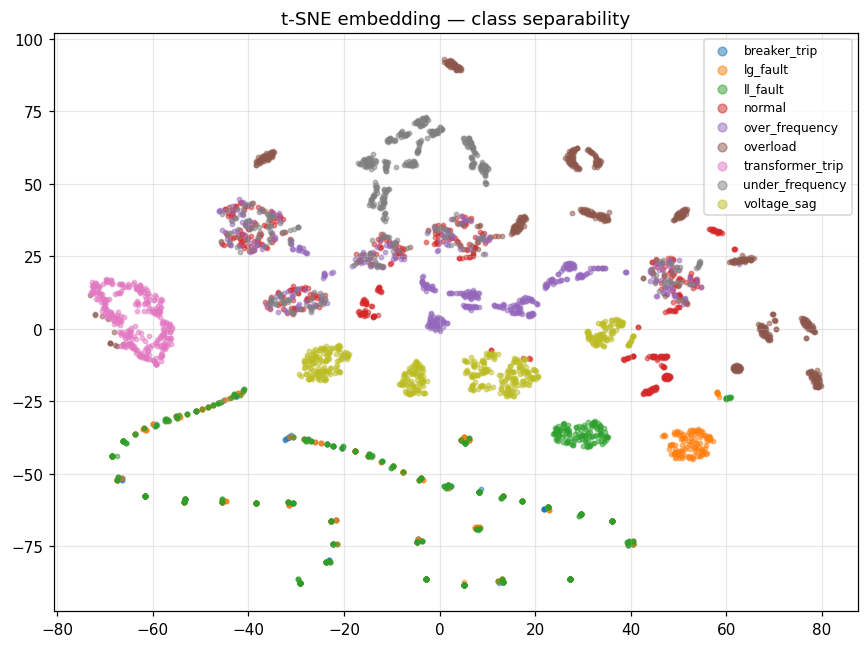

In [44]:

from sklearn.manifold import TSNE
samp_small = pd.concat([g.sample(min(len(g),500), random_state=42) for _, g in clean.groupby('label')]).reset_index(drop=True)
Xs = StandardScaler().fit_transform(samp_small[NUMERIC])
emb = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(Xs)

fig, ax = plt.subplots(figsize=(8,6))
for lab in samp_small.label.unique():
    m = samp_small.label.values == lab
    ax.scatter(emb[m,0], emb[m,1], s=8, alpha=.5, label=lab)
ax.legend(markerscale=2, fontsize=8); ax.set_title('t-SNE embedding — class separability')
plt.tight_layout(); plt.show()


In [45]:

# top loading features per PC
loadings = pd.DataFrame(pca.components_.T, index=NUMERIC, columns=['PC1','PC2'])
loadings.sort_values('PC1', ascending=False)


,PC1,PC2
S_MVA,0.452464,-0.152247
Q_Mvar,0.439585,-0.190238
P_MW,0.435429,0.031563
loading_pct,0.405009,-0.133340
I_hv_A,0.403836,-0.197868
V_lv_kV,0.190545,0.538532
V_hv_kV,0.163859,0.535797
PF,0.148834,0.551769
freq_Hz,-0.004314,-0.034045


## 14. Feature Engineering Candidates

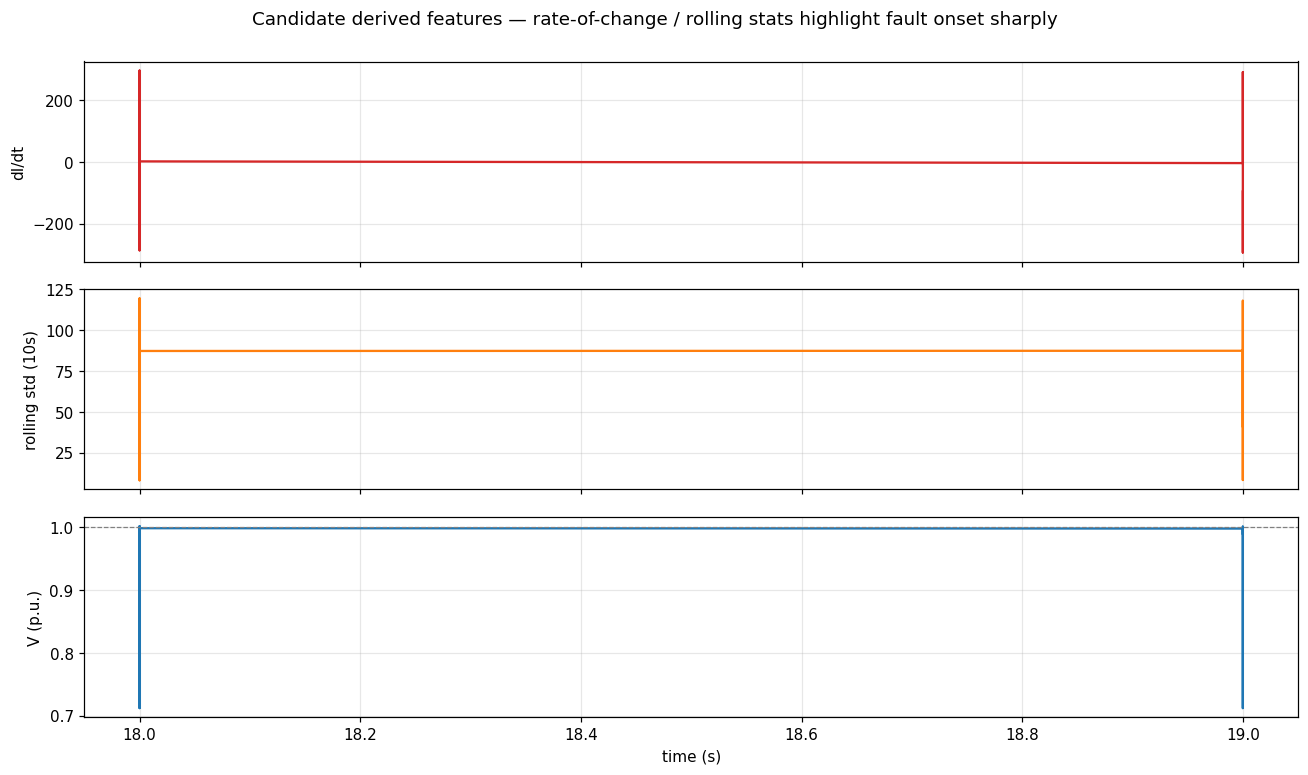

In [46]:

eng = df[df.substation=="Laverie/Sechage SN1"].sort_values('time_s').copy()
eng['dV_dt'] = eng.V_hv_kV.diff()
eng['dI_dt'] = eng.I_hv_A.diff()
eng['I_roll_mean_10s'] = eng.I_hv_A.rolling(10).mean()
eng['I_roll_std_10s']  = eng.I_hv_A.rolling(10).std()
eng['V_pu'] = eng.V_hv_kV / 60.0  # nominal 60kV base

fig, axes = plt.subplots(3,1, figsize=(12,7), sharex=True)
window = eng.iloc[3700:3850]
axes[0].plot(window.time_s, window.dI_dt, color='tab:red'); axes[0].set_ylabel('dI/dt')
axes[1].plot(window.time_s, window.I_roll_std_10s, color='tab:orange'); axes[1].set_ylabel('rolling std (10s)')
axes[2].plot(window.time_s, window.V_pu, color='tab:blue'); axes[2].axhline(1.0, ls='--', color='gray', lw=.8); axes[2].set_ylabel('V (p.u.)')
axes[2].set_xlabel('time (s)')
fig.suptitle('Candidate derived features — rate-of-change / rolling stats highlight fault onset sharply', y=1.0)
plt.tight_layout(); plt.show()


In [47]:

# feature idea checklist (engineering judgment, not fitted)
candidates = pd.DataFrame({
    'feature': ['dV/dt','dI/dt','rolling std (5-10s)','V in p.u.','S3 = P^2+Q^2 residual',
                'time since last event (per substation)','rate-of-change of PF','breaker/relay one-hot flags'],
    'rationale': [
        'sharp derivative spike = fault onset marker',
        'current surge detection, faster than absolute threshold',
        'volatility jump ahead of steady-state fault value',
        'normalizes across substations with different nominal V',
        'sanity/derived redundancy check, can catch sensor faults',
        'captures maintenance/recovery patterns, cool-down effects',
        'PF collapse frequently precedes visible V/I fault signature',
        'categorical state is itself informative, cheap to encode'
    ]
})
candidates


,feature,rationale
0,dV/dt,sharp derivative spike = fault onset marker
1,dI/dt,"current surge detection, faster than absolute ..."
2,rolling std (5-10s),volatility jump ahead of steady-state fault value
3,V in p.u.,normalizes across substations with different n...
4,S3 = P^2+Q^2 residual,"sanity/derived redundancy check, can catch sen..."
5,time since last event (per substation),"captures maintenance/recovery patterns, cool-d..."
6,rate-of-change of PF,PF collapse frequently precedes visible V/I fa...
7,breaker/relay one-hot flags,"categorical state is itself informative, cheap..."


## 15. Windowing Strategy for Sequence Models

In [48]:

WINDOW_S, STRIDE_S = 20, 5  # informed by section 3: events last ~15s

def make_windows(frame, window=WINDOW_S, stride=STRIDE_S):
    frame = frame.sort_values('time_s').reset_index(drop=True)
    X, y = [], []
    for start in range(0, len(frame)-window, stride):
        w = frame.iloc[start:start+window]
        X.append(w[NUMERIC].values)
        y.append(w.label.mode().iloc[0])  # majority label in window
    return np.array(X), np.array(y)

Xw, yw = make_windows(df[df.substation=="U Calcination SN3"])
print(Xw.shape, yw.shape)
pd.Series(yw).value_counts()


(5996, 20, 9) (5996,)


normal    5996
Name: count, dtype: int64

In [49]:

# window-label distribution across ALL substations (majority-vote labeling)
all_y = []
for sub in SUBS:
    _, yw_s = make_windows(df[df.substation==sub])
    all_y.extend(yw_s)
pd.Series(all_y).value_counts().to_frame('n_windows').assign(pct=lambda d: (d.n_windows/d.n_windows.sum()*100).round(2))


,n_windows,pct
normal,65956,100.0


## 16. Train / Validation / Test Split Strategy

In [50]:

# WRONG: random row split -> leaks adjacent timesteps of the same event across splits.
# RIGHT: split by discrete event blocks (and/or by contiguous time ranges) so no event straddles splits.
event_ids = events[['substation','block']].drop_duplicates().reset_index(drop=True)
rng = np.random.RandomState(42)
shuffled = event_ids.sample(frac=1, random_state=42)
n = len(shuffled)
train_ev = shuffled.iloc[:int(.7*n)]
val_ev   = shuffled.iloc[int(.7*n):int(.85*n)]
test_ev  = shuffled.iloc[int(.85*n):]
print(f"events -> train {len(train_ev)}, val {len(val_ev)}, test {len(test_ev)}")

# also recommend a hard time-based holdout for realistic deployment simulation
time_cut1, time_cut2 = df.time_s.quantile([.7, .85])
print(f"Time-based alternative: train < t={time_cut1:.0f}s, val {time_cut1:.0f}-{time_cut2:.0f}s, test > {time_cut2:.0f}s")


events -> train 49875, val 10687, test 10688
Time-based alternative: train < t=104s, val 104-127s, test > 127s


## 17. Class Imbalance — Recommended Weights

In [51]:

from sklearn.utils.class_weight import compute_class_weight
classes = np.array(sorted(df.label.unique().tolist()))
weights = compute_class_weight('balanced', classes=classes, y=df.label)
pd.Series(weights, index=classes).sort_values(ascending=False).to_frame('class_weight')


,class_weight
breaker_trip,244.444444
transformer_trip,122.222222
overload,20.370370
ll_fault,4.700855
lg_fault,4.143126
under_frequency,2.777778
over_frequency,1.709402
voltage_sag,1.709402
normal,0.143791


## 18. Summary of Findings
- **Scale**: 396,000 rows, 11 substations × 36,000 s (10h) balanced panel, no duplicate keys, ~1.5MB/substation.
- **Imbalance**: 95.9% normal; rarest class (`under_frequency`) = 165 rows / 11 events → class-weighted loss, PR-AUC/F1 not accuracy.
- **Label leakage/error**: ~193 `normal` rows have non-healthy `equip_status`, ~351 have tripped/pickup relay → clean/relabel before training.
- **Missing data**: 382 rows (0.1%) NaN across all electrical columns simultaneously, likely solver non-convergence at topology change → interpolate or drop.
- **Physical bounds**: PF/frequency/current all within plausible ranges; a handful of loading_pct spikes trace back to the same mislabeled rows above.
- **Fault co-occurrence**: majority of fault timesteps are single-substation events; multi-substation simultaneous faults are rare (check §4) → mostly local, not systemic, disturbances.
- **Multicollinearity**: P/Q/S/I highly correlated (high VIF) → drop redundant features for non-sequence models; irrelevant for LSTM/CNN.
- **KS separation**: current/voltage/loading separate `lg_fault`/`ll_fault`/`overload` cleanly from normal; frequency-based classes need `freq_Hz`/PF explicitly, not just current.
- **Stationarity**: normal-operation current is stationary (ADF) with short-range autocorrelation (~few seconds) → supports short sequence windows.
- **Event duration**: faults last ~15s on average → window length 20s / stride 5s is a reasonable default; produces a still-imbalanced but tractable window-level dataset (see §15).
- **Split strategy**: split by discrete event blocks or hard time cutoff, never by random row, to avoid leaking adjacent timesteps of the same event across train/val/test.
- **Separability**: PCA/t-SNE show faults separate well from normal but `over_frequency`/`under_frequency`/`voltage_sag` overlap more → engineer explicit frequency/PF features.
- **Substation coverage**: fault events reasonably distributed across all 11 substations, no single-site bias.